Imports

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import OPTICS
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import pyodbc
import pandas as pd
import geopandas as gpd




/tmp/ipykernel_235102/3369584664.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", num_clusters)  # Use a colormap with distinct colors


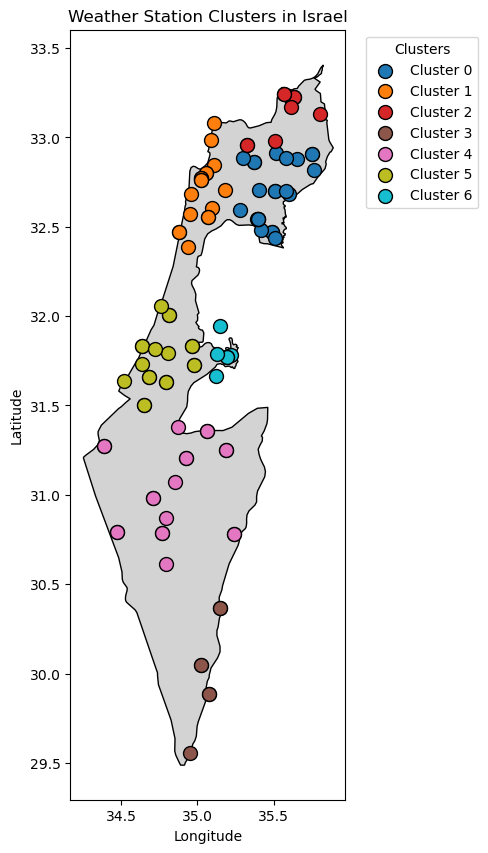

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define all clusters with their station names
clusters = {
    "Cluster 0": [
        "AFULA NIR HAEMEQ", "AMMIAD", "AVNE ETAN", 
        "AYYELET HASHARHAR", "BET ZAYDA", "DEIR HANNA", 
        "EDEN FARM", "ESHHAR", "GAMLA",  
        "KEFAR NAHUM", "MAALE GILBOA", 
        "MASSADA", "SEDE ELIYYAHU", "TAVOR KADOORIE", 
        "TEL YOSEF", "YAVNEEL", "ZEMAH"
    ],
    "Cluster 1": [
        "AFEQ", "EN HAHORESH", "EN HASHOFET", "EN KARMEL", "GALED", 
        "HADERA PORT", "HAIFA REFINERIES", "HAIFA TECHNION", "HAIFA UNIVERSITY", 
        "NEWE YAAR", "ROSH HANIQRA", "SHAVE ZIYYON", "ZIKHRON YAAQOV"
    ],
    "Cluster 2": [
        "HARASHIM", "MEROM GOLAN PICMAN", "ZEFAT HAR KENAAN", 
        "DAFNA", "KEFAR BLUM", "KEFAR GILADI"
    ],
    "Cluster 3": [
        "ELAT",   "YOTVATA","NEOT SMADAR","PARAN"
    ],
    "Cluster 4": [
        "ARAD", "ASHALIM", "AVDAT", "EZUZ",  
        "MIZPE RAMON",  "NEVATIM", "SEDE BOQER", 
        "SHANI", "ZOMET HANEGEV","LAHAV","BESOR FARM","HAZEVA"   #"BESOR FARM" moved here from cluster center,"HAZEVA" moved here from cluster arava 
    ],
    "Cluster 5": [
        "ASHDOD PORT", "ASHQELON PORT", "BEIT JIMAL",  "BET DAGAN", 
        "DOROT", "GAT", "HAFEZ HAYYIM",  "NAHSHON", "NEGBA", 
        "NIZZAN", "QEVUZAT YAVNE", "TEL AVIV COAST"
    ],
    "Cluster 6": [
        "HAR HARASHA", "JERUSALEM CENTRE", "JERUSALEM GIVAT RAM", "ROSH ZURIM", "ZOVA"
    ]
}

# Load station metadata from CSV
stations_df = pd.read_csv('/home/weizyuv/Deep Learning Preprocess/stations_meta_data.csv')

# Normalize station names
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Load Israel map from GeoJSON
israel_map = gpd.read_file('/home/weizyuv/Deep Learning Preprocess/il.json')

# Convert filtered DataFrame to GeoDataFrame for plotting
stations_df = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Assign a unique color to each cluster
num_clusters = len(clusters)
colors = plt.cm.get_cmap("tab10", num_clusters)  # Use a colormap with distinct colors

# Plot the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Iterate through each cluster and plot stations
for i, (cluster_name, cluster_stations) in enumerate(clusters.items()):
    # Filter stations belonging to the current cluster
    cluster_gdf = stations_df[stations_df['Station'].isin(cluster_stations)]
    
    # Plot stations with a unique color
    ax.scatter(cluster_gdf['Longitude'], cluster_gdf['Latitude'], 
               color=colors(i), label=cluster_name, s=100, edgecolor='black')

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Weather Station Clusters in Israel')

# Move the legend outside the plot
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


Define Cluster

In [2]:
#Center: cluster = [
      
#         "ASHDOD PORT", "ASHQELON PORT", "BEIT JIMAL",  "BET DAGAN", 
#         "DOROT", "GAT", "HAFEZ HAYYIM",  "NAHSHON", "NEGBA", 
#         "NIZZAN", "QEVUZAT YAVNE", "TEL AVIV COAST"
#     ]
#NorthWest (1): cluster = [
#         "AFEQ", "EN HAHORESH", "EN HASHOFET", "EN KARMEL", "GALED", 
#         "HADERA PORT", "HAIFA REFINERIES", "HAIFA TECHNION", "HAIFA UNIVERSITY", 
#         "NEWE YAAR", "ROSH HANIQRA", "SHAVE ZIYYON", "ZIKHRON YAAQOV"
#     ]
cluster = [
        "ARAD", "ASHALIM", "AVDAT", "EZUZ",  
        "MIZPE RAMON",  "NEVATIM", "SEDE BOQER", 
        "SHANI", "ZOMET HANEGEV","LAHAV","BESOR FARM","HAZEVA"   #"BESOR FARM" moved here from cluster center,"HAZEVA" moved here from cluster arava 
    ]
    
cluster = [
        "ARAD", "ASHALIM", "AVDAT", "EZUZ",  
        "MIZPE RAMON",  "NEVATIM", "SEDE BOQER", 
        "SHANI", "ZOMET HANEGEV","LAHAV","BESOR FARM","HAZEVA"   #"BESOR FARM" moved here from cluster center,"HAZEVA" moved here from cluster arava 
    ]

cluster = [
    # Cluster 0
    "AFULA NIR HAEMEQ", "AMMIAD", "AVNE ETAN",
  # <-- missing one (now added)
    "BET ZAYDA", "DEIR HANNA",
    "EDEN FARM", "ESHHAR", "GAMLA",
    "KEFAR NAHUM", "MAALE GILBOA",
    "MASSADA", "SEDE ELIYYAHU", "TAVOR KADOORIE",
    "TEL YOSEF", "YAVNEEL", "ZEMAH",

    # Cluster 1
    "AFEQ", "EN HAHORESH", "EN HASHOFET", "EN KARMEL", "GALED",
    "HADERA PORT", "HAIFA REFINERIES", "HAIFA TECHNION", "HAIFA UNIVERSITY",
    "NEWE YAAR", "ROSH HANIQRA", "SHAVE ZIYYON", "ZIKHRON YAAQOV",

    # Cluster 2
    "HARASHIM", "MEROM GOLAN PICMAN", "ZEFAT HAR KENAAN",
    "DAFNA", "KEFAR BLUM", "KEFAR GILADI",

    # Cluster 3
    "ELAT", "YOTVATA", "NEOT SMADAR", "PARAN",

    # Cluster 4
    "ARAD", "ASHALIM", "AVDAT", "EZUZ",
    "MIZPE RAMON", "NEVATIM", "SEDE BOQER",
    "SHANI", "ZOMET HANEGEV", "LAHAV", "BESOR FARM", "HAZEVA",

    # Cluster 5
    "ASHDOD PORT", "ASHQELON PORT", "BEIT JIMAL", "BET DAGAN",
    "DOROT", "GAT", "HAFEZ HAYYIM",
    "NAHSHON", "NEGBA", "NIZZAN", "QEVUZAT YAVNE", "TEL AVIV COAST",

    # Cluster 6
    "HAR HARASHA", "JERUSALEM CENTRE", "JERUSALEM GIVAT RAM",
    "ROSH ZURIM", "ZOVA"
]

print(len(cluster))


68


Plot The Cluster

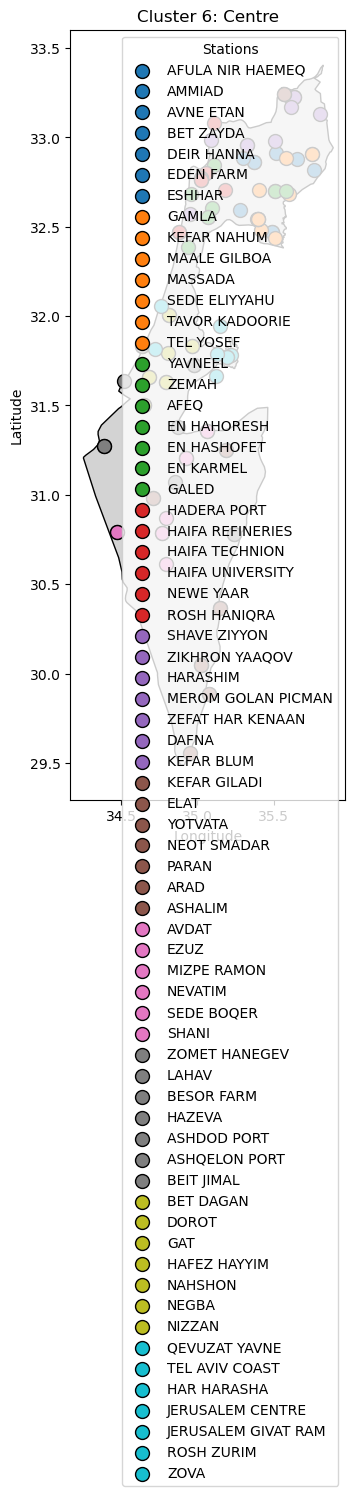

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np



# Load station metadata from CSV
stations_df = pd.read_csv('/home/weizyuv/Deep Learning Preprocess/stations_meta_data.csv')  # Adjust path

# Normalize station names for matching
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Filter to keep only the stations that are part of the specified cluster list
stations_df = stations_df[stations_df['Station'].isin(cluster)]

# Load Israel map from GeoJSON
israel_map = gpd.read_file('/home/weizyuv/Deep Learning Preprocess/il.json')  # Adjust path

# Convert filtered DataFrame to GeoDataFrame for plotting
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Generate a unique color for each station
np.random.seed(42)  # For reproducibility
colors = plt.cm.tab10(np.linspace(0, 1, len(cluster)))  # Use colormap for distinct colors
station_colors = dict(zip(cluster, colors))  # Assign colors to stations

# Plot the map with clustered stations
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the clustered stations with unique colors
scatter_plots = []
for station, color in station_colors.items():
    station_data = gdf_clustered_stations[gdf_clustered_stations['Station'] == station]
    sc = ax.scatter(
        station_data['Longitude'], station_data['Latitude'], 
        color=color, s=100, edgecolor='black'
    )
    scatter_plots.append(sc)  # Store scatter plot handles for the legend

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Cluster 6: Centre')

# Add legend with station names and colors
plt.legend(scatter_plots, cluster, title="Stations", loc="upper right")

# Show plot
plt.show()


Calculate Resulotion

In [3]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

import math

def calc_res(pixel_spacing_km, padding, stations_df, israel_map, bil_directory):
    """
    Plot a rectangle based on the most northern, southern, eastern, and western stations
    with padding, and mark the resolution pixels on the map. Return the matrix with pixel locations.

    Parameters:
    pixel_spacing_km (float): Desired spacing between pixels in kilometers.
    padding (tuple): Padding as (longitude_padding, latitude_padding).
    stations_df (DataFrame): DataFrame with station coordinates (Longitude, Latitude, Height).
    israel_map (GeoDataFrame): GeoDataFrame of the map of Israel.
    bil_directory (str): Directory containing the .bil files.

    Returns:
    numpy.ndarray: A matrix of pixel locations with their corresponding longitude, latitude, and height.
    """
    # Calculate the bounding box with padding
    min_lat = stations_df['Latitude'].min() - padding[1]
    max_lat = stations_df['Latitude'].max() + padding[1]
    min_lon = stations_df['Longitude'].min() - padding[0]
    max_lon = stations_df['Longitude'].max() + padding[0]

    # Convert pixel spacing from km to degrees
    lat_spacing_deg = pixel_spacing_km / 111.32  # Latitude conversion
    avg_latitude = (max_lat + min_lat) / 2  # Midpoint latitude for better longitude scaling
    lon_spacing_deg = pixel_spacing_km / (111.32 * math.cos(math.radians(avg_latitude)))  # Longitude conversion

    # Compute resolution (number of pixels)
    width_pixels = int((max_lon - min_lon) / lon_spacing_deg)
    height_pixels = int((max_lat - min_lat) / lat_spacing_deg)

    print(f"Auto-calculated resolution: {width_pixels}x{height_pixels} pixels for {pixel_spacing_km} km spacing.")

   
# Example usage


# Load station metadata
stations_df = pd.read_csv(r'/home/weizyuv/Deep Learning Preprocess/stations_meta_data.csv')
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')
stations_df = stations_df[stations_df['Station'].isin(cluster)]

# Ensure Height column is numeric
stations_df['Height'] = pd.to_numeric(stations_df['height'], errors='coerce')

# Drop duplicate rows based on 'Station', 'Latitude', 'Longitude', and 'Height'
stations_df = stations_df.drop_duplicates(subset=['Station', 'Latitude', 'Longitude', 'Height'])

# Load Israel map
israel_map = gpd.read_file(r'/home/weizyuv/Deep Learning Preprocess/il.json')

# Directory containing .bil files
bil_directory = r'C:\תואר שני\מחקר נגה\height_data\bil files'

# Run the function


In [4]:
pixel_spacing_km = 3  # 3 km per pixel
padding = (0.001, 0.01)  # Adjust as needed

# Run function with auto resolution
pixel_matrix = calc_res(pixel_spacing_km, padding, stations_df, israel_map, bil_directory)


Auto-calculated resolution: 44x137 pixels for 3 km spacing.


Create Rectangle

Stations kept: 68


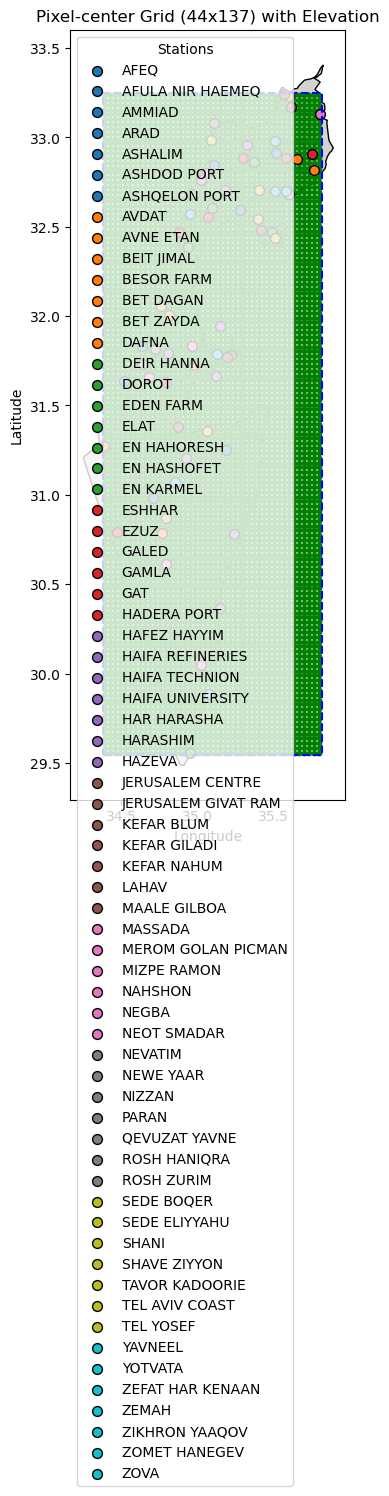

pixel_matrix shape: (44, 137, 3)
[[[ 34.395706  29.556131 794.      ]
  [ 34.395706  29.583197 823.      ]]

 [[ 34.428326  29.556131 894.      ]
  [ 34.428326  29.583197 867.      ]]]


In [5]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

def plot_station_rectangle_with_grid_on_map(resolution, padding, stations_df, israel_map, bil_directory):
    """
    Creates an HxW grid of *pixel centers* (not corners), attaches elevation from DEM (.bil),
    plots the rectangle+grid+stations, and returns pixel_matrix with shape (W, H, 3):
      pixel_matrix[i, j] = [lon_center, lat_center, elevation]
    where i indexes longitude (width), j indexes latitude (height).
    """
    # --- Bounding box with padding ---
    min_lat = stations_df['Latitude'].min() - padding[1]
    max_lat = stations_df['Latitude'].max() + padding[1]
    min_lon = stations_df['Longitude'].min() - padding[0]
    max_lon = stations_df['Longitude'].max() + padding[0]

    width_pixels, height_pixels = resolution

    # --- Grid as *centers* (exactly width_pixels x height_pixels) ---
    lon_edges = np.linspace(min_lon, max_lon, width_pixels + 1)
    lat_edges = np.linspace(min_lat, max_lat, height_pixels + 1)
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    pixel_matrix = np.full((width_pixels, height_pixels, 3), np.nan, dtype=np.float32)
    # fill lon/lat
    pixel_matrix[:, :, 0] = lon_centers[:, None]
    pixel_matrix[:, :, 1] = lat_centers[None, :]

    # --- Load DEMs ---
    bil_files = [os.path.join(bil_directory, f) for f in os.listdir(bil_directory) if f.endswith('.bil')]
    if len(bil_files) == 0:
        raise FileNotFoundError(f"No .bil files found in: {bil_directory}")

    dem_datasets = [rasterio.open(bil) for bil in bil_files]

    # --- Vectorized elevation sampling across multiple DEM tiles ---
    # Flatten points
    pts_lon = pixel_matrix[:, :, 0].ravel()
    pts_lat = pixel_matrix[:, :, 1].ravel()
    elev = np.full_like(pts_lon, np.nan, dtype=np.float32)

    for dem in dem_datasets:
        # only sample points that fall in this DEM bounds AND still missing elevation
        in_bounds = (
            (pts_lon >= dem.bounds.left) & (pts_lon <= dem.bounds.right) &
            (pts_lat >= dem.bounds.bottom) & (pts_lat <= dem.bounds.top)
        )
        need = np.isnan(elev) & in_bounds
        if not np.any(need):
            continue

        coords = list(zip(pts_lon[need], pts_lat[need]))
        sampled = np.array([v[0] for v in dem.sample(coords)], dtype=np.float32)

        nodata = dem.nodata
        if nodata is not None:
            sampled[sampled == nodata] = np.nan

        elev[need] = sampled

    # reshape back
    pixel_matrix[:, :, 2] = elev.reshape((width_pixels, height_pixels))

    # Close DEM files
    for dem in dem_datasets:
        dem.close()

    # --- Plot ---
    np.random.seed(42)
    colors = plt.cm.tab10(np.linspace(0, 1, len(stations_df)))
    station_colors = dict(zip(stations_df['Station'], colors))

    fig, ax = plt.subplots(figsize=(10, 10))
    israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

    # Rectangle (bbox)
    ax.plot([min_lon, max_lon, max_lon, min_lon, min_lon],
            [min_lat, min_lat, max_lat, max_lat, min_lat],
            color='blue', linestyle='--', label='Bounding Box')

    # Grid centers
    ax.scatter(pixel_matrix[:, :, 0], pixel_matrix[:, :, 1],
               color='green', s=10, label='Pixel Centers')

    # Stations
    scatter_plots = []
    for station, color in station_colors.items():
        station_data = stations_df[stations_df['Station'] == station]
        sc = ax.scatter(
            station_data['Longitude'], station_data['Latitude'],
            color=color, s=50, edgecolor='black'
        )
        scatter_plots.append((sc, station))

    ax.legend(
        [sc[0] for sc in scatter_plots],
        [sc[1] for sc in scatter_plots],
        title="Stations", loc="upper left"
    )

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Pixel-center Grid ({width_pixels}x{height_pixels}) with Elevation')
    plt.show()

    return pixel_matrix


# ===== Load station metadata (clean + consistent Height column) =====
stations_df = pd.read_csv(r'/home/weizyuv/Deep Learning Preprocess/stations_meta_data.csv')

stations_df['Station'] = (
    stations_df['Station'].astype(str).str.upper()
    .str.replace('STATION_', '', regex=False)
    .str.replace('_', ' ', regex=False)
)

# unify Height column name
if 'height' in stations_df.columns and 'Height' not in stations_df.columns:
    stations_df = stations_df.rename(columns={'height': 'Height'})
stations_df['Height'] = pd.to_numeric(stations_df['Height'], errors='coerce')

# filter to cluster
stations_df = stations_df[stations_df['Station'].isin(cluster)].copy()

# drop duplicates by Station (keep first occurrence)
stations_df = stations_df.drop_duplicates(subset=['Station']).copy()
print("Stations kept:", len(stations_df))

# ===== Load Israel map =====
israel_map = gpd.read_file(r'/home/weizyuv/Deep Learning Preprocess/il.json')

# ===== DEM directory =====
bil_directory = r'/home/weizyuv/Deep Learning Preprocess/height_data/bil files'

# ===== Run =====
pixel_matrix = plot_station_rectangle_with_grid_on_map(
    resolution=(44, 137),
    padding=(0.01, 0.01),
    stations_df=stations_df,
    israel_map=israel_map,
    bil_directory=bil_directory
)

print("pixel_matrix shape:", pixel_matrix.shape)  # (26, 82, 3)
print(pixel_matrix[:2, :2, :])


Weights Clculation

In [8]:
import numpy as np
import pandas as pd
import math

# ===== Load k values from CSV =====
k_values_path = r"/home/weizyuv/Deep Learning Preprocess/k_values.csv"
k_values_df = pd.read_csv(k_values_path)

# {Feature: k_value}
feature_k_dict = dict(zip(k_values_df['Feature'], k_values_df['k']))
print("Loaded k per feature:", feature_k_dict)

def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km) for lat/lon degrees."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    c = 2 * math.asin(math.sqrt(a))
    return R * c

def calculate_feature_weights(
    pixel_matrix,
    stations_df,
    station_order,
    weight_function="idw",
    p=2,              # IDW power
    k_exp=1.0,        # exponential k
    r_km=10.0,        # constant radius in km
    alpha_km_per_m=0.0,  # height influence: effective_km = sqrt(d_km^2 + (alpha*dh_m)^2)
    eps_km=1e-6,      # avoid division by zero
):
    """
    Compute weights for all features using REAL UNITS (km + height scaling), with a fixed station order.

    Returns:
      feature_weights_dict[feature] = weights_matrix with shape (W, H, S)
      and weights sum to ~1 per pixel.
    """
    W, H, _ = pixel_matrix.shape

    # Ensure consistent station ordering + consistent Height column name
    sdf = stations_df.copy()
    if 'height' in sdf.columns and 'Height' not in sdf.columns:
        sdf = sdf.rename(columns={'height': 'Height'})
    if 'Height' not in sdf.columns:
        raise KeyError("stations_df must contain a 'Height' column (or 'height' to be renamed).")

    sdf['Station'] = sdf['Station'].astype(str).str.upper()
    missing = [s for s in station_order if s not in set(sdf['Station'])]
    if missing:
        raise ValueError(f"Stations missing from stations_df (check naming): {missing[:10]}{'...' if len(missing)>10 else ''}")

    # Reorder to station_order
    sdf = sdf.set_index('Station').loc[station_order].reset_index()

    station_lon = sdf['Longitude'].to_numpy(dtype=np.float64)  # (S,)
    station_lat = sdf['Latitude'].to_numpy(dtype=np.float64)   # (S,)
    station_h_m = sdf['Height'].to_numpy(dtype=np.float64)     # (S,)
    S = len(station_order)

    # Pre-extract pixel coordinates
    pix_lon = pixel_matrix[:, :, 0].astype(np.float64)
    pix_lat = pixel_matrix[:, :, 1].astype(np.float64)
    pix_h_m = pixel_matrix[:, :, 2].astype(np.float64)

    feature_weights_dict = {}

    for feature, k_value in feature_k_dict.items():
        # k_value can be used as a per-feature multiplier on height influence (your idea),
        # but now applied in real units.
        # effective height scale:
        alpha_eff = alpha_km_per_m * float(k_value)

        weights_matrix = np.zeros((W, H, S), dtype=np.float64)

        for i in range(W):
            for j in range(H):
                lon_p = pix_lon[i, j]
                lat_p = pix_lat[i, j]
                h_p   = pix_h_m[i, j]

                # Horizontal distances in KM (S,)
                d_km = np.array(
                    [haversine_distance_km(lat_p, lon_p, station_lat[s], station_lon[s]) for s in range(S)],
                    dtype=np.float64
                )

                # Height diffs in meters (S,)
                if np.isnan(h_p):
                    # If pixel elevation missing, ignore height term (fallback to horizontal only)
                    dh_m = np.zeros(S, dtype=np.float64)
                else:
                    dh_m = np.abs(station_h_m - h_p)

                # Effective distance in KM (S,)
                d_eff = np.sqrt(d_km**2 + (alpha_eff * dh_m)**2)

                # Handle exact-hit / tiny distance: if any station essentially on the pixel, make it weight 1
                min_idx = int(np.argmin(d_eff))
                if d_eff[min_idx] <= eps_km:
                    w = np.zeros(S, dtype=np.float64)
                    w[min_idx] = 1.0
                    weights_matrix[i, j, :] = w
                    continue

                # Apply weighting function using real km distances
                if weight_function == "idw":
                    w = 1.0 / np.power(d_eff + eps_km, p)
                elif weight_function == "exponential":
                    w = np.exp(-k_exp * d_eff)
                elif weight_function == "linear":
                    d_max = np.max(d_eff)
                    # linearly decreasing with distance to [0..1], clamp at 0
                    w = np.maximum(0.0, 1.0 - (d_eff / (d_max + eps_km)))
                elif weight_function == "constant":
                    w = (d_eff <= r_km).astype(np.float64)
                else:
                    raise ValueError(f"Unknown weight function: {weight_function}")

                w_sum = w.sum()
                if w_sum > 0:
                    w /= w_sum
                else:
                    # fallback: uniform
                    w[:] = 1.0 / S

                weights_matrix[i, j, :] = w

        feature_weights_dict[feature] = weights_matrix

    # Quick sanity check (optional): max deviation from 1
    # (leave it on; it catches bugs early)
    feat0 = next(iter(feature_weights_dict))
    sdev = np.max(np.abs(feature_weights_dict[feat0].sum(axis=2) - 1.0))
    print(f"[Sanity] Max |sum(weights)-1| for '{feat0}': {sdev:.3e}")

    return feature_weights_dict


# ====== YOU MUST DEFINE THIS ONCE AND USE IT EVERYWHERE ======
# station_order must match how you will later build feature_values in create_channels_gpu
# Use the SAME normalization you used for stations_df['Station'] (uppercase, spaces)
station_order = (
    stations_df['Station'].astype(str).str.upper().tolist()
)

# ===== Compute weights dictionaries (choose ONE to use; others optional) =====
# Height scaling: start small. Example: 0.001 km per meter = 1 km per 1000m height diff.
# Given your note (height diffs ~100m), alpha_km_per_m=0.001 means 100m -> 0.1km effective.
alpha_km_per_m = 0.001

weights_idw = calculate_feature_weights(
    pixel_matrix,
    stations_df,
    station_order=station_order,
    weight_function="idw",
    p=2,
    alpha_km_per_m=alpha_km_per_m,
)

weights_exponential = calculate_feature_weights(
    pixel_matrix,
    stations_df,
    station_order=station_order,
    weight_function="exponential",
    k_exp=1.0,
    alpha_km_per_m=alpha_km_per_m,
)

weights_linear = calculate_feature_weights(
    pixel_matrix,
    stations_df,
    station_order=station_order,
    weight_function="linear",
    alpha_km_per_m=alpha_km_per_m,
)

weights_constant = calculate_feature_weights(
    pixel_matrix,
    stations_df,
    station_order=station_order,
    weight_function="constant",
    r_km=25.0,   # example radius
    alpha_km_per_m=alpha_km_per_m,
)

print("IDW Weights Dictionary Created.")
print("Exponential Weights Dictionary Created.")
print("Linear Weights Dictionary Created.")
print("Constant Weights Dictionary Created.")

# Example: Accessing a specific feature's weight matrix
feature_name = "tmp_air_wet"
if feature_name in weights_idw:
    print(f"Weights for {feature_name} (IDW) at pixel (0,0):")
    print(weights_idw[feature_name][0, 0, :])
else:
    print(f"Feature '{feature_name}' not found in k_values.csv; available example keys:",
          list(weights_idw.keys())[:10])
import numpy as np
import pandas as pd
import math

# =============================
# 1) CANONICAL station order
# =============================
# Use the SAME order you used to load stations and build feature matrices:
station_order = station_order_loaded  # <<<<< THE ONLY ORDER YOU USE FROM NOW ON

# Ensure stations_df is in that exact order (and has Height)
sdf = stations_df.copy()
if 'height' in sdf.columns and 'Height' not in sdf.columns:
    sdf = sdf.rename(columns={'height': 'Height'})
sdf['Station'] = sdf['Station'].astype(str).str.upper().str.strip()

missing = [s for s in station_order if s not in set(sdf['Station'])]
if missing:
    raise ValueError(f"Stations missing from stations_df: {missing[:10]}")

sdf = sdf.set_index('Station').loc[station_order].reset_index()

# =============================
# 2) k-values dict (already loaded in your notebook)
# =============================
# feature_k_dict must exist, e.g. from your previous cell
# feature_k_dict = {...}

# =============================
# 3) distance helpers
# =============================
def haversine_distance_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    return 2 * R * math.asin(math.sqrt(a))

def calculate_feature_weights(
    pixel_matrix,
    stations_df_ordered,      # MUST be in station_order
    station_order,
    weight_function="idw",
    p=2,
    k_exp=1.0,
    r_km=10.0,
    alpha_km_per_m=0.001,
    eps_km=1e-6
):
    W, H, _ = pixel_matrix.shape

    # Extract station vectors in EXACT order
    st_lon = stations_df_ordered['Longitude'].to_numpy(np.float64)
    st_lat = stations_df_ordered['Latitude'].to_numpy(np.float64)
    st_h   = stations_df_ordered['Height'].to_numpy(np.float64)
    S = len(station_order)

    pix_lon = pixel_matrix[:, :, 0].astype(np.float64)
    pix_lat = pixel_matrix[:, :, 1].astype(np.float64)
    pix_h   = pixel_matrix[:, :, 2].astype(np.float64)

    out = {}

    for feature, k_feat in feature_k_dict.items():
        alpha_eff = alpha_km_per_m * float(k_feat)  # per-feature height scaling
        Wmat = np.zeros((W, H, S), dtype=np.float64)

        for i in range(W):
            for j in range(H):
                lon_p, lat_p, h_p = pix_lon[i, j], pix_lat[i, j], pix_h[i, j]

                d_km = np.array(
                    [haversine_distance_km(lat_p, lon_p, st_lat[s], st_lon[s]) for s in range(S)],
                    dtype=np.float64
                )

                if np.isnan(h_p):
                    dh_m = np.zeros(S, dtype=np.float64)
                else:
                    dh_m = np.abs(st_h - h_p)

                d_eff = np.sqrt(d_km**2 + (alpha_eff * dh_m)**2)

                # exact hit safeguard
                m = int(np.argmin(d_eff))
                if d_eff[m] <= eps_km:
                    w = np.zeros(S, dtype=np.float64)
                    w[m] = 1.0
                    Wmat[i, j, :] = w
                    continue

                if weight_function == "idw":
                    w = 1.0 / np.power(d_eff + eps_km, p)
                elif weight_function == "exponential":
                    w = np.exp(-k_exp * d_eff)
                elif weight_function == "linear":
                    dmax = np.max(d_eff)
                    w = np.maximum(0.0, 1.0 - d_eff / (dmax + eps_km))
                elif weight_function == "constant":
                    w = (d_eff <= r_km).astype(np.float64)
                else:
                    raise ValueError(weight_function)

                ws = w.sum()
                if ws > 0:
                    w /= ws
                else:
                    w[:] = 1.0 / S

                Wmat[i, j, :] = w

        out[feature] = Wmat

    # Sanity
    f0 = next(iter(out))
    print(f"[Sanity] Max |sum(weights)-1| for '{f0}': {np.max(np.abs(out[f0].sum(axis=2)-1.0)):.3e}")
    return out

# =============================
# 4) Recompute weights (in the correct order)
# =============================
weights_idw = calculate_feature_weights(
    pixel_matrix=pixel_matrix,
    stations_df_ordered=sdf,
    station_order=station_order,
    weight_function="idw",
    p=2,
    alpha_km_per_m=0.001
)

print("Recomputed weights_idw with canonical station_order.")



Loaded k per feature: {'prs_stn': 237.6071131, 'max_wet_temp': 14.80307493, 'tmp_air_wet': 20.92850644, 'min_wet_temp': 17.09035392, 'tmp_air_dry': 3.734632257, 'tmp_dew_pnt': 3.318591011, 'max_heat_stress': 2.665264407, 'min_heat_stress': 16.31536378, 'max_dry_temp': 2.319985669, 'min_dry_temp': 10.63657381}
[Sanity] Max |sum(weights)-1| for 'prs_stn': 6.661e-16
[Sanity] Max |sum(weights)-1| for 'prs_stn': 4.441e-16
[Sanity] Max |sum(weights)-1| for 'prs_stn': 6.661e-16
[Sanity] Max |sum(weights)-1| for 'prs_stn': 1.110e-16
IDW Weights Dictionary Created.
Exponential Weights Dictionary Created.
Linear Weights Dictionary Created.
Constant Weights Dictionary Created.
Weights for tmp_air_wet (IDW) at pixel (0,0):
[0.00427634 0.00488334 0.00393219 0.0143926  0.02267158 0.00913416
 0.01097436 0.02955347 0.00399733 0.0096786  0.01621912 0.00779486
 0.00392352 0.00329461 0.00412292 0.0124474  0.00511434 0.18801436
 0.00581454 0.00497298 0.00479167 0.00410778 0.03123126 0.00513323
 0.00382183

Loading Stations From CSV

In [7]:
import os
import pandas as pd

# ====== CONFIG ======
load_directory = r'/home/weizyuv/Deep Learning Preprocess/Stations Daily Data 03_08_2025'
cutoff_year = 2005

# IMPORTANT: define ONE canonical station order (same as weights!)
# cluster currently contains station names with spaces (e.g. "TEL AVIV COAST")
station_order = [s.upper().strip() for s in cluster]  # keep spaces

# helper: station name -> filename
def station_to_filename(station_name: str) -> str:
    # your files are like "TEL_AVIV_COAST.csv"
    return station_name.replace(" ", "_") + ".csv"

# helper: filename -> station name
def filename_to_station(file_name: str) -> str:
    # "TEL_AVIV_COAST.csv" -> "TEL AVIV COAST"
    base = os.path.splitext(file_name)[0]
    return base.replace("_", " ").upper().strip()

# ====== LOAD ======
stations = {}
missing_files = []
bad_files = []

for station in station_order:
    file_name = station_to_filename(station)
    file_path = os.path.join(load_directory, file_name)

    if not os.path.exists(file_path):
        missing_files.append(file_name)
        continue

    try:
        df = pd.read_csv(file_path)

        # Date parsing + cutoff filter
        if 'Date' not in df.columns:
            print(f"Warning: 'Date' column not found in {file_name}. Skipping this station.")
            bad_files.append(file_name)
            continue

        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date'])
        df = df[df['Date'].dt.year >= cutoff_year].copy()
        df = df.sort_values('Date')

        # Fix known bad column name
        if 'Rain (degC)' in df.columns and 'Rain (mm)' not in df.columns:
            df = df.rename(columns={'Rain (degC)': 'Rain (mm)'})
            print(f"Renamed 'Rain (degC)' -> 'Rain (mm)' in {file_name}")

        # OPTIONAL: ensure numeric columns (except Date)
        for c in df.columns:
            if c != 'Date':
                df[c] = pd.to_numeric(df[c], errors='coerce')

        # Store using canonical station name (WITH SPACES)
        stations[station] = df

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")
        bad_files.append(file_name)

# ====== REPORT ======
print(f"\nLoaded {len(stations)}/{len(station_order)} stations.")
if missing_files:
    print("Missing CSV files (not found):")
    for f in missing_files[:30]:
        print("  -", f)
    if len(missing_files) > 30:
        print(f"  ... and {len(missing_files) - 30} more")

if bad_files:
    print("Bad/Skipped CSV files:")
    for f in bad_files:
        print("  -", f)

# IMPORTANT: this is the station list you must use everywhere downstream
# (weights + create_channels_gpu)
station_order_loaded = [s for s in station_order if s in stations]
print("\nFinal station_order_loaded length:", len(station_order_loaded))

# Sanity: show a quick peek instead of printing huge dfs
for s in station_order_loaded[:5]:
    print(f"\n{s} head():")
    print(stations[s].head())



Loaded 68/68 stations.

Final station_order_loaded length: 68

AFULA NIR HAEMEQ head():
      year  month  day  prs_stn  prs_sea_lvl  prs_lvl_hgt  tmp_air_dry  \
3222  2005      1    1      NaN          NaN          NaN      11.7875   
3223  2005      1    2      NaN          NaN          NaN      12.5250   
3224  2005      1    3      NaN          NaN          NaN      13.2000   
3225  2005      1    4      NaN          NaN          NaN      12.6500   
3226  2005      1    5      NaN          NaN          NaN      11.4500   

      tmp_air_wet  tmp_dew_pnt  hmd_rlt  ...  max_dry_temp  min_dry_temp  \
3222       8.3250       4.2750   62.750  ...          20.3           5.6   
3223      10.9000       9.2250   80.500  ...          17.4           7.9   
3224      11.3500       9.5750   79.500  ...          18.1          10.2   
3225      11.2125       9.8250   83.500  ...          16.3           9.8   
3226      10.0000       8.5625   82.875  ...          16.6           9.1   

      max

Debug

Built mat for max_dry_temp: (15, 68) (T,S) over 2023-07-25..2023-08-08


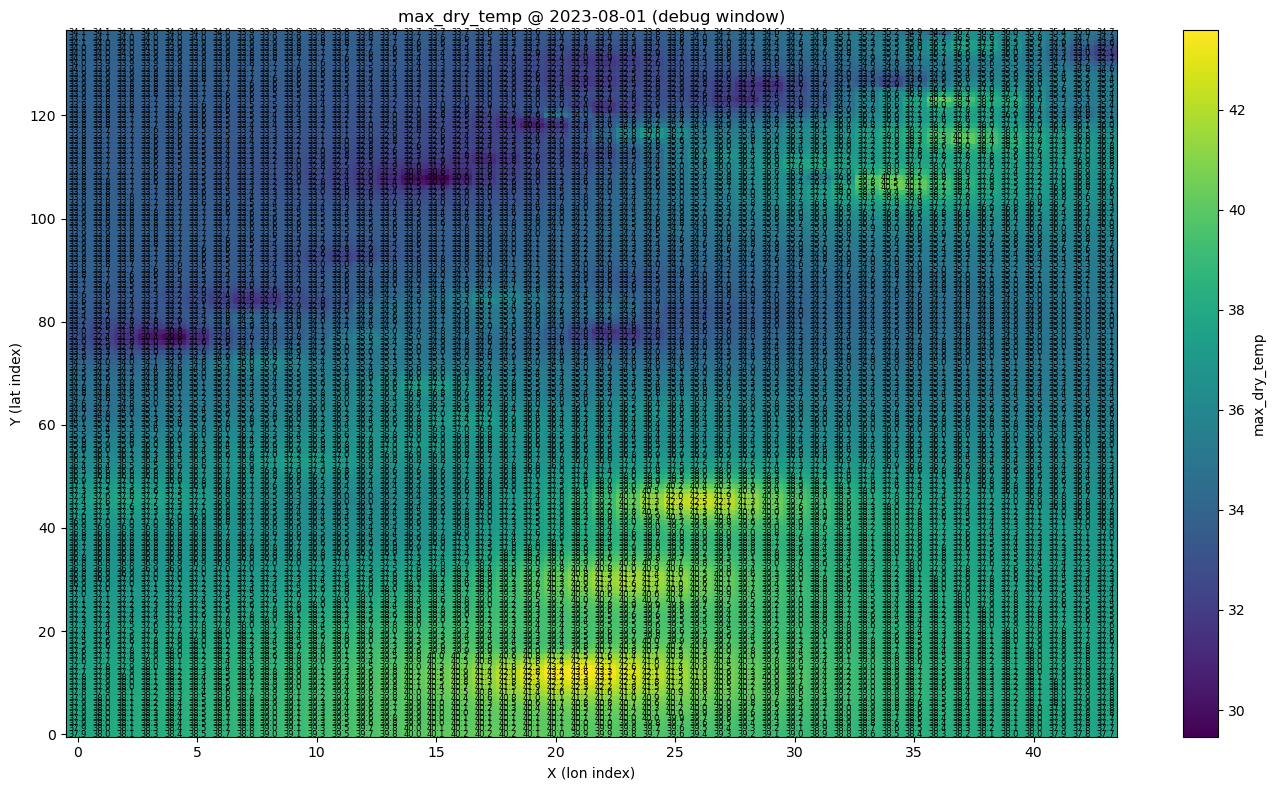

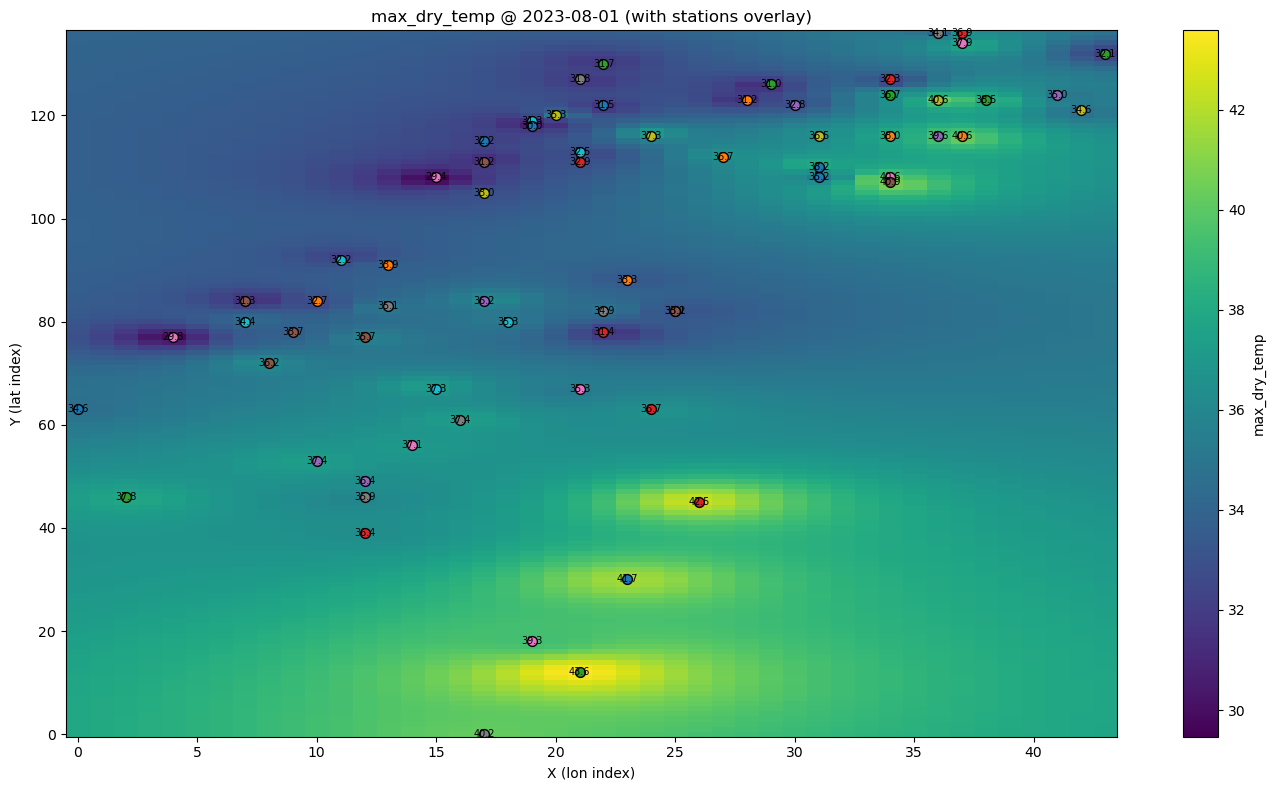

Station-vs-frame error stats for max_dry_temp @ 2023-08-01:
  mean(station - frame) = 0.013
  MAE                  = 0.119
  max abs error         = 0.616
         station  station_val  frame_val       err  abs_err  dist_to_pixel_km  pix_i  pix_j
HAIFA UNIVERSITY         30.0  30.615749 -0.615749 0.615749          1.363066     19    118
         MASSADA         40.6  40.067780  0.532220 0.532220          1.375048     37    116
       EDEN FARM         40.6  40.124214  0.475786 0.475786          1.937301     34    108
   SEDE ELIYYAHU         40.9  40.538036  0.361964 0.361964          1.549972     34    107
        HARASHIM         31.0  31.360279 -0.360279 0.360279          1.653457     29    126
      KEFAR BLUM         37.9  37.542053  0.357947 0.357947          1.595319     37    134
ZEFAT HAR KENAAN         32.3  32.657093 -0.357093 0.357093          1.493940     34    127
       TEL YOSEF         38.2  37.860439  0.339561 0.339561          1.849065     31    110
       NEWE YAAR 

In [10]:
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt

# ===== CONFIG =====
feat = "max_dry_temp"
target_date = pd.Timestamp("2023-08-01")

# build only a small range for debug
start_date = target_date - pd.Timedelta(days=7)
end_date   = target_date + pd.Timedelta(days=7)
time_periods_dbg = pd.date_range(start=start_date, end=end_date, freq="D")

# station order MUST match weights axis
station_order = station_order_loaded  # from your loading cell

# ===== build (T,S) matrix for ONE feature =====
def _agg_series(s: pd.Series, how: str) -> pd.Series:
    if how == "mean": return s.groupby(level=0).mean()
    if how == "max":  return s.groupby(level=0).max()
    if how == "min":  return s.groupby(level=0).min()
    if how == "sum":  return s.groupby(level=0).sum()
    raise ValueError(how)

# per-feature aggregation (for this feature we want max)
FEATURE_AGG = {"max_dry_temp": "max"}

def build_feature_matrix_one(stations, station_order, feature, time_periods):
    cols = []
    how = FEATURE_AGG.get(feature, "mean")

    for st in station_order:
        df = stations[st].copy()
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).set_index("Date").sort_index()

        if feature not in df.columns:
            cols.append(pd.Series(index=time_periods, data=np.nan, name=st))
            continue

        s = pd.to_numeric(df[feature], errors="coerce")
        s = _agg_series(s, how)  # dedupe by day if needed
        s = s.reindex(time_periods)
        s.name = st
        cols.append(s)

    mat = pd.concat(cols, axis=1).to_numpy(dtype=np.float32)  # (T,S)
    return mat

mat_cpu = build_feature_matrix_one(stations, station_order, feat, time_periods_dbg)
T, S = mat_cpu.shape
print(f"Built mat for {feat}: {mat_cpu.shape} (T,S) over {time_periods_dbg[0].date()}..{time_periods_dbg[-1].date()}")

# ===== generate frames for ONE feature =====
assert feat in weights_idw, f"{feat} not in weights_idw keys. Available: {list(weights_idw.keys())}"
W, H, _ = pixel_matrix.shape

Wfeat = cp.asarray(weights_idw[feat], dtype=cp.float32)  # (W,H,S)

frames = []
for t in range(T):
    vals = cp.asarray(mat_cpu[t], dtype=cp.float32)  # (S,)
    valid = ~cp.isnan(vals)
    if int(valid.sum()) == 0:
        frame = cp.full((W, H), cp.nan, dtype=cp.float32)
    else:
        wv = Wfeat[:, :, valid]        # (W,H,Sv)
        vv = vals[valid]               # (Sv,)
        num = cp.sum(wv * vv, axis=2)
        den = cp.sum(wv, axis=2)
        frame = cp.where(den > 0, num / den, cp.nan)
    frames.append(frame)

# ===== pick frame index for target_date =====
tp = pd.DatetimeIndex(time_periods_dbg)
t_idx = int(np.where(tp == target_date)[0][0])
frame = cp.asnumpy(frames[t_idx]).astype(np.float32)  # (W,H)

# ===== plot with colors + numbers =====
img = frame.T  # (H,W) for display
H2, W2 = img.shape

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(img, origin="lower", aspect="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(feat)

ax.set_title(f"{feat} @ {target_date.date()} (debug window)")
ax.set_xlabel("X (lon index)")
ax.set_ylabel("Y (lat index)")

for y in range(H2):
    for x in range(W2):
        v = img[y, x]
        ax.text(x, y, "NaN" if np.isnan(v) else f"{v:.1f}",
                ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

feat = "max_dry_temp"
date = pd.Timestamp("2023-08-01")

# frame is (W,H) cupy or numpy. If you still have it as cp, convert:
# frame = cp.asnumpy(frames[t_idx]).astype(np.float32)
# If you only have img (H,W) displayed, use img.T to recover (W,H).
frame_wh = frame  # (W,H) numpy float32 from your debug cell

# ---- build quick lookup: station -> value on that date ----
station_order = station_order_loaded

station_vals = {}
for st in station_order:
    df = stations[st].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    if feat not in df.columns:
        station_vals[st] = np.nan
        continue

    # for max_dry_temp we want max if duplicates
    s = pd.to_numeric(df[feat], errors="coerce").groupby(level=0).max()
    station_vals[st] = float(s.loc[date]) if date in s.index else np.nan

# ---- map station lat/lon to nearest pixel index (i,j) in pixel_matrix (W,H,3) ----
pix_lon = pixel_matrix[:, :, 0]  # (W,H)
pix_lat = pixel_matrix[:, :, 1]  # (W,H)

def nearest_pixel_idx(lon, lat):
    # brute-force nearest; W*H is small (~26*82)
    d2 = (pix_lon - lon)**2 + (pix_lat - lat)**2
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    return int(i), int(j)

# ---- plot heatmap + station markers ----
img = frame_wh.T  # (H,W) for imshow

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(img, origin="lower", aspect="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(feat)

ax.set_title(f"{feat} @ {date.date()} (with stations overlay)")
ax.set_xlabel("X (lon index)")
ax.set_ylabel("Y (lat index)")

# overlay stations
errs = []
for _, row in stations_df.iterrows():
    st = row["Station"]
    lon = float(row["Longitude"])
    lat = float(row["Latitude"])

    i, j = nearest_pixel_idx(lon, lat)
    frame_val = frame_wh[i, j]   # (W,H)
    st_val = station_vals.get(st, np.nan)

    # plot marker at (x=i, y=j) on the displayed image (which is transposed)
    ax.scatter(i, j, s=50, edgecolor="black")
    # annotate with station value
    if np.isfinite(st_val):
        ax.text(i, j, f"{st_val:.1f}", ha="center", va="center", fontsize=7)

    if np.isfinite(st_val) and np.isfinite(frame_val):
        errs.append(st_val - frame_val)

plt.tight_layout()
plt.show()

if errs:
    errs = np.array(errs, dtype=np.float32)
    print(f"Station-vs-frame error stats for {feat} @ {date.date()}:")
    print(f"  mean(station - frame) = {errs.mean():.3f}")
    print(f"  MAE                  = {np.mean(np.abs(errs)):.3f}")
    print(f"  max abs error         = {np.max(np.abs(errs)):.3f}")
else:
    print("No station errors computed (maybe missing station values on that date).")
import numpy as np
import pandas as pd
import math

feat = "max_dry_temp"
date = pd.Timestamp("2023-08-01")

# --- haversine km ---
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = phi2 - phi1
    dl = math.radians(lon2 - lon1)
    a = (math.sin(dphi/2)**2 +
         math.cos(phi1)*math.cos(phi2)*math.sin(dl/2)**2)
    return 2*R*math.asin(math.sqrt(a))

# frame_wh is your (W,H) numpy frame from the debug plotting cell
frame_wh = frame  # (W,H)

pix_lon = pixel_matrix[:, :, 0]
pix_lat = pixel_matrix[:, :, 1]
W, H = pix_lon.shape

def nearest_pixel_idx_km(st_lon, st_lat):
    # brute-force over grid (small)
    best = (None, None, 1e18)
    for i in range(W):
        for j in range(H):
            d = haversine_km(st_lat, st_lon, float(pix_lat[i, j]), float(pix_lon[i, j]))
            if d < best[2]:
                best = (i, j, d)
    return best  # (i,j,d_km)

# station value on that date
def station_value_on_date(st):
    df = stations[st].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).set_index("Date").sort_index()
    if feat not in df.columns:
        return np.nan
    s = pd.to_numeric(df[feat], errors="coerce").groupby(level=0).max()
    return float(s.loc[date]) if date in s.index else np.nan

rows = []
for _, r in stations_df.iterrows():
    st = r["Station"]
    st_lon = float(r["Longitude"])
    st_lat = float(r["Latitude"])
    st_val = station_value_on_date(st)

    i, j, d_km = nearest_pixel_idx_km(st_lon, st_lat)
    fr_val = float(frame_wh[i, j]) if np.isfinite(frame_wh[i, j]) else np.nan

    err = (st_val - fr_val) if (np.isfinite(st_val) and np.isfinite(fr_val)) else np.nan
    rows.append([st, st_val, fr_val, err, abs(err) if np.isfinite(err) else np.nan, d_km, i, j])

df_err = pd.DataFrame(rows, columns=["station", "station_val", "frame_val", "err", "abs_err", "dist_to_pixel_km", "pix_i", "pix_j"])
df_err = df_err.sort_values("abs_err", ascending=False)

print(df_err.head(15).to_string(index=False))
print("\nSummary:")
print("MAE:", df_err["abs_err"].mean())
print("Max abs:", df_err["abs_err"].max())
print("Median dist to pixel (km):", df_err["dist_to_pixel_km"].median())



[Sanity] Max |sum(weights)-1| for 'prs_stn': 6.661e-16


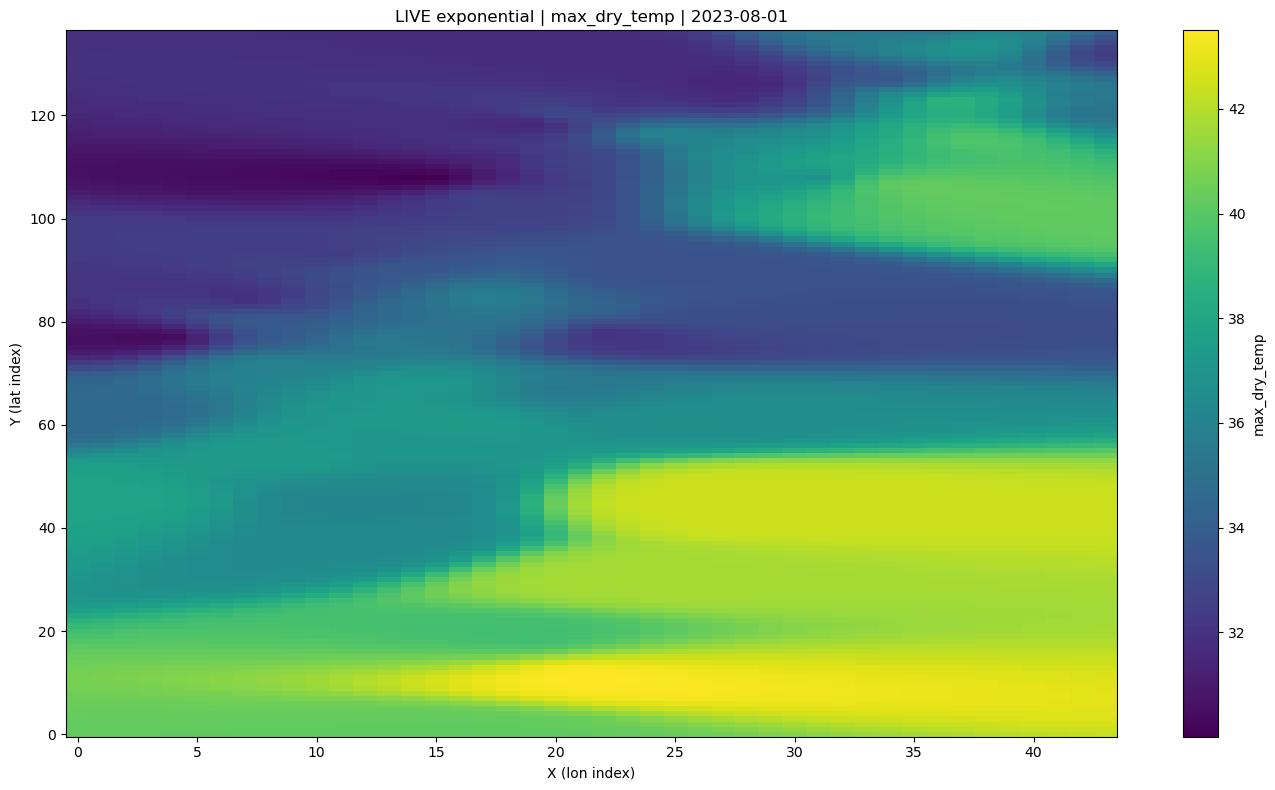

In [17]:
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
weights_exponential = calculate_feature_weights(
    pixel_matrix=pixel_matrix,
    stations_df_ordered=sdf,
    station_order=station_order,
    weight_function="exponential",
    k_exp=0.2,   # much safer than 1.0
    alpha_km_per_m=0.001
)
feat = "max_dry_temp"
target_date = pd.Timestamp("2023-08-01")

# same matrix you already built
mat_cpu = build_feature_matrix_one(stations, station_order, feat, time_periods_dbg)
tp = pd.DatetimeIndex(time_periods_dbg)
t_idx = int(np.where(tp == target_date)[0][0])

# use EXP weights instead of IDW
assert feat in weights_exponential, f"{feat} missing in weights_exponential"
Wfeat = cp.asarray(weights_exponential[feat], dtype=cp.float32)

vals = cp.asarray(mat_cpu[t_idx], dtype=cp.float32)
valid = ~cp.isnan(vals)

if int(valid.sum()) == 0:
    live_exp = cp.full((pixel_matrix.shape[0], pixel_matrix.shape[1]), cp.nan, dtype=cp.float32)
else:
    wv = Wfeat[:, :, valid]
    vv = vals[valid]
    num = cp.sum(wv * vv, axis=2)
    den = cp.sum(wv, axis=2)
    live_exp = cp.where(den > 0, num / den, cp.nan)

live_exp = cp.asnumpy(live_exp).astype(np.float32)

plt.figure(figsize=(14, 8))
plt.imshow(live_exp.T, origin="lower", aspect="auto")
plt.colorbar(label=feat)
plt.title(f"LIVE exponential | {feat} | {target_date.date()}")
plt.xlabel("X (lon index)")
plt.ylabel("Y (lat index)")
plt.tight_layout()
plt.show()

Channels Creation (exp)

In [30]:
import cupy as cp
import numpy as np
import pandas as pd
from tqdm import tqdm

# Per-feature daily aggregation when duplicates exist on same Date
# (tune if needed)
FEATURE_AGG = {
    "max_wet_temp": "max",
    "min_wet_temp": "min",
    "max_dry_temp": "max",
    "min_dry_temp": "min",
    "max_heat_stress": "max",
    "min_heat_stress": "min",
    "prs_stn": "mean",
    "tmp_air_wet": "mean",
    "tmp_air_dry": "mean",
    "tmp_dew_pnt": "mean",
}

def _dedupe_daily(series: pd.Series, how: str) -> pd.Series:
    """Deduplicate same-date rows (if any) using how on a DateTimeIndex."""
    g = series.groupby(level=0)
    if how == "mean": return g.mean()
    if how == "max":  return g.max()
    if how == "min":  return g.min()
    if how == "sum":  return g.sum()
    raise ValueError(f"Unknown agg: {how}")

def _resample(series: pd.Series, aggregation: str, how: str) -> pd.Series:
    """Resample daily series into weekly/monthly using same how."""
    if aggregation == "daily":
        return series
    if aggregation == "weekly":
        r = series.resample("W-MON")
    elif aggregation == "monthly":
        r = series.resample("MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    if how == "mean": return r.mean()
    if how == "max":  return r.max()
    if how == "min":  return r.min()
    if how == "sum":  return r.sum()
    raise ValueError(f"Unknown agg: {how}")

def create_channels_gpu(
    pixel_matrix,
    weights_dict,
    stations,
    selected_features,
    station_order,
    aggregation="daily",
    start_date=None,
    end_date=None,
    store_in_memory=False,
    on_frame=None,   # callback: on_frame(feature, timestamp, frame_cupy)
):
    """
    Correct + faster channel generation.

    Key fixes:
      - station_order is explicit (must match weights axis!)
      - precomputes (T,S) per feature on CPU (no per-day .loc slicing)
      - can stream frames via on_frame() to avoid huge RAM usage

    Returns:
      - if store_in_memory: (channels_dict, time_periods)
      - else: (None, time_periods)
    """
    W, H, _ = pixel_matrix.shape
    S = len(station_order)

    # ---- sanity: weights station axis matches station_order length ----
    for f in selected_features:
        if f in weights_dict:
            if weights_dict[f].shape[2] != S:
                raise ValueError(
                    f"weights_dict['{f}'] has S={weights_dict[f].shape[2]} but station_order has {S}. "
                    "You have a station-order mismatch."
                )

    # ---- ensure Date index for each station (without mutating original dfs too hard) ----
    stations_idx = {}
    mins, maxs = [], []
    for st in station_order:
        df = stations[st].copy()
        if "Date" not in df.columns:
            raise KeyError(f"Station '{st}' has no Date column")
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
        stations_idx[st] = df
        if len(df.index):
            mins.append(df.index.min())
            maxs.append(df.index.max())

    if not mins:
        raise ValueError("No valid dates found in stations")

    # ---- determine time_periods ----
    start = pd.Timestamp(start_date) if start_date is not None else min(mins)
    end   = pd.Timestamp(end_date)   if end_date   is not None else max(maxs)

    if aggregation == "daily":
        time_periods = pd.date_range(start=start, end=end, freq="D")
    elif aggregation == "weekly":
        time_periods = pd.date_range(start=start, end=end, freq="W-MON")
    elif aggregation == "monthly":
        time_periods = pd.date_range(start=start, end=end, freq="MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    T = len(time_periods)
    print(f"time_periods={T} | stations={S} | grid={W}x{H} | aggregation={aggregation}")

    # ---- build CPU feature matrices: mat[feature] = (T,S) float32 ----
    mats = {}
    for feat in selected_features:
        if feat not in weights_dict:
            print(f"Warning: no weights for '{feat}', skipping feature.")
            continue

        how = FEATURE_AGG.get(feat, "mean")
        cols = []

        for st in station_order:
            df = stations_idx[st]
            if feat not in df.columns:
                cols.append(pd.Series(index=time_periods, data=np.nan, name=st))
                continue

            s = pd.to_numeric(df[feat], errors="coerce")
            s = _dedupe_daily(s, how)                # dedupe same-day rows (if any)
            s = _resample(s, aggregation, how)       # daily/weekly/monthly
            s = s.reindex(time_periods)
            s.name = st
            cols.append(s)

        mats[feat] = pd.concat(cols, axis=1).to_numpy(dtype=np.float32)  # (T,S)

    channels = {feat: [] for feat in mats.keys()} if store_in_memory else None

    # ---- GPU loop ----
    total = len(mats) * T
    with tqdm(total=total, desc="Generating frames") as pbar:
        for feat, mat_cpu in mats.items():
            Wfeat = cp.asarray(weights_dict[feat], dtype=cp.float32)  # (W,H,S)

            for t_idx in range(T):
                vals = cp.asarray(mat_cpu[t_idx], dtype=cp.float32)   # (S,)
                valid = ~cp.isnan(vals)

                if int(valid.sum()) == 0:
                    frame = cp.full((W, H), cp.nan, dtype=cp.float32)
                else:
                    wv = Wfeat[:, :, valid]     # (W,H,Sv)
                    vv = vals[valid]            # (Sv,)
                    num = cp.sum(wv * vv, axis=2)
                    den = cp.sum(wv, axis=2)
                    frame = cp.where(den > 0, num / den, cp.nan)

                ts = time_periods[t_idx]

                if on_frame is not None:
                    on_frame(feat, ts, frame)

                if store_in_memory:
                    channels[feat].append(frame)

                pbar.update(1)

    return channels, time_periods


In [31]:
import os
import numpy as np
import pandas as pd
import cupy as cp

# ===== PATHS =====
save_dir = r"/home/weizyuv/Deep Learning Preprocess/Cluster All_ISRAEL/Daily Aggregation EXP 05_01_2026_ALL_ISRAEL_HIGHRES"
os.makedirs(save_dir, exist_ok=True)

# Load feature list
k_values_path = r"/home/weizyuv/Deep Learning Preprocess/k_values.csv"
k_values_df = pd.read_csv(k_values_path)
selected_features = k_values_df["Feature"].tolist()

aggregation = "daily"

# IMPORTANT: must match weights station axis (you already fixed weights with this order)
station_order = station_order_loaded

# OPTIONAL: limit date range for debugging
# start_date = "2023-07-25"
# end_date   = "2023-08-10"
start_date = None
end_date   = None

def process_and_save_channels(weights_dict, weight_function_name, skip_features=None):
    skip_features = set(skip_features or [])

    # Callback to save each frame immediately (no huge RAM)
    def saver(feat, ts, frame_cp):
        if feat in skip_features:
            return
        date_str = pd.Timestamp(ts).strftime("%Y-%m-%d")
        fname = f"{weight_function_name}_{feat}_{date_str}.npy"
        fpath = os.path.join(save_dir, fname)

        # CuPy -> NumPy before saving
        frame_np = cp.asnumpy(frame_cp).astype(np.float32)
        np.save(fpath, frame_np)

    # Generate + save (streaming)
    _, time_periods = create_channels_gpu(
        pixel_matrix=pixel_matrix,
        weights_dict=weights_dict,
        stations=stations,
        selected_features=selected_features,
        station_order=station_order,
        aggregation=aggregation,
        start_date=start_date,
        end_date=end_date,
        store_in_memory=False,
        on_frame=saver
    )

    print(f"\n✅ Done saving {weight_function_name} frames: {time_periods[0].date()} .. {time_periods[-1].date()}")

# Run
process_and_save_channels(weights_exponential, "exponential", skip_features={"prs_stn"})
# process_and_save_channels(weights_idw, "idw", skip_features={"prs_stn"})
# process_and_save_channels(weights_linear, "linear", skip_features={"prs_stn"})
# process_and_save_channels(weights_constant, "constant", skip_features={"prs_stn"})

print("\nAll frames saved successfully!")


time_periods=7486 | stations=68 | grid=44x137 | aggregation=daily


Generating frames: 100%|██████████| 74860/74860 [04:42<00:00, 265.42it/s]


✅ Done saving exponential frames: 2005-01-01 .. 2025-06-30

All frames saved successfully!


Channels cration (exp_v2)

In [20]:
import cupy as cp
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# Per-feature daily aggregation when duplicates exist on same day
# ============================================================
FEATURE_AGG = {
    "max_wet_temp": "max",
    "min_wet_temp": "min",
    "max_dry_temp": "max",
    "min_dry_temp": "min",
    "max_heat_stress": "max",
    "min_heat_stress": "min",
    "prs_stn": "mean",
    "tmp_air_wet": "mean",
    "tmp_air_dry": "mean",
    "tmp_dew_pnt": "mean",
}

def _dedupe_daily(series: pd.Series, how: str) -> pd.Series:
    """
    Deduplicate rows that belong to the same normalized calendar day.
    series must already have a normalized DateTimeIndex.
    """
    g = series.groupby(level=0)

    if how == "mean":
        return g.mean()
    if how == "max":
        return g.max()
    if how == "min":
        return g.min()
    if how == "sum":
        return g.sum()

    raise ValueError(f"Unknown agg: {how}")

def _resample(series: pd.Series, aggregation: str, how: str) -> pd.Series:
    """
    Resample daily series into weekly/monthly using the same aggregation rule.
    """
    if aggregation == "daily":
        return series

    if aggregation == "weekly":
        r = series.resample("W-MON")
    elif aggregation == "monthly":
        r = series.resample("MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    if how == "mean":
        return r.mean()
    if how == "max":
        return r.max()
    if how == "min":
        return r.min()
    if how == "sum":
        return r.sum()

    raise ValueError(f"Unknown agg: {how}")

def create_channels_gpu(
    pixel_matrix,
    weights_dict,
    stations,
    selected_features,
    station_order,
    aggregation="daily",
    start_date=None,
    end_date=None,
    store_in_memory=False,
    on_frame=None,   # callback: on_frame(feature, timestamp, frame_cupy)
):
    """
    Generate interpolated frames using the SAME logic as the validated live test:

        vals  -> valid mask
        wv    = Wfeat[:, :, valid]
        vv    = vals[valid]
        num   = sum(wv * vv)
        den   = sum(wv)
        frame = num / den

    Important:
      - station_order MUST match the weights station axis
      - Date is normalized to calendar day before dedupe/resample
      - can stream frames via on_frame() to avoid huge RAM usage

    Returns:
      - if store_in_memory=True : (channels_dict, time_periods)
      - else                    : (None, time_periods)
    """
    W, H, _ = pixel_matrix.shape
    S = len(station_order)

    # ------------------------------------------------------------
    # Sanity checks
    # ------------------------------------------------------------
    missing_station_keys = [st for st in station_order if st not in stations]
    if missing_station_keys:
        raise KeyError(
            f"These stations are missing from 'stations': "
            f"{missing_station_keys[:10]}{'...' if len(missing_station_keys) > 10 else ''}"
        )

    for f in selected_features:
        if f in weights_dict:
            if weights_dict[f].shape[2] != S:
                raise ValueError(
                    f"weights_dict['{f}'] has station axis {weights_dict[f].shape[2]} "
                    f"but station_order has length {S}. Station-order mismatch."
                )

    # ------------------------------------------------------------
    # Prepare station dataframes with normalized daily Date index
    # ------------------------------------------------------------
    stations_idx = {}
    mins, maxs = [], []

    for st in station_order:
        df = stations[st].copy()

        if "Date" not in df.columns:
            raise KeyError(f"Station '{st}' has no 'Date' column")

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).copy()

        # IMPORTANT: normalize to calendar day
        df["Date"] = df["Date"].dt.normalize()

        df = df.sort_values("Date").set_index("Date")
        stations_idx[st] = df

        if len(df.index) > 0:
            mins.append(df.index.min())
            maxs.append(df.index.max())

    if not mins:
        raise ValueError("No valid dates found in stations")

    # ------------------------------------------------------------
    # Build global time axis
    # ------------------------------------------------------------
    start = pd.Timestamp(start_date).normalize() if start_date is not None else min(mins)
    end   = pd.Timestamp(end_date).normalize()   if end_date   is not None else max(maxs)

    if aggregation == "daily":
        time_periods = pd.date_range(start=start, end=end, freq="D")
    elif aggregation == "weekly":
        time_periods = pd.date_range(start=start, end=end, freq="W-MON")
    elif aggregation == "monthly":
        time_periods = pd.date_range(start=start, end=end, freq="MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    T = len(time_periods)
    print(f"time_periods={T} | stations={S} | grid={W}x{H} | aggregation={aggregation}")

    # ------------------------------------------------------------
    # Build CPU matrices: mats[feature] = (T, S)
    # ------------------------------------------------------------
    mats = {}

    for feat in selected_features:
        if feat not in weights_dict:
            print(f"Warning: no weights for '{feat}', skipping feature.")
            continue

        how = FEATURE_AGG.get(feat, "mean")
        cols = []

        for st in station_order:
            df = stations_idx[st]

            if feat not in df.columns:
                cols.append(pd.Series(index=time_periods, data=np.nan, name=st))
                continue

            s = pd.to_numeric(df[feat], errors="coerce")
            s = _dedupe_daily(s, how)          # same-day duplicates
            s = _resample(s, aggregation, how)
            s = s.reindex(time_periods)
            s.name = st
            cols.append(s)

        mats[feat] = pd.concat(cols, axis=1).to_numpy(dtype=np.float32)  # (T,S)

    if len(mats) == 0:
        raise ValueError("No valid features remained after matching with weights_dict")

    channels = {feat: [] for feat in mats.keys()} if store_in_memory else None

    # ------------------------------------------------------------
    # Move weights to GPU once per feature
    # ------------------------------------------------------------
    gpu_weights = {
        feat: cp.asarray(weights_dict[feat], dtype=cp.float32)
        for feat in mats.keys()
    }

    # ------------------------------------------------------------
    # Generate frames using the SAME logic as the validated live test
    # ------------------------------------------------------------
    total = len(mats) * T
    with tqdm(total=total, desc="Generating frames") as pbar:
        for feat, mat_cpu in mats.items():
            Wfeat = gpu_weights[feat]  # (W,H,S)

            for t_idx in range(T):
                vals = cp.asarray(mat_cpu[t_idx], dtype=cp.float32)  # (S,)
                valid = ~cp.isnan(vals)

                if int(valid.sum()) == 0:
                    frame = cp.full((W, H), cp.nan, dtype=cp.float32)
                else:
                    # EXACT same logic as your validated live exponential test
                    wv = Wfeat[:, :, valid]   # (W,H,Sv)
                    vv = vals[valid]          # (Sv,)
                    num = cp.sum(wv * vv, axis=2)
                    den = cp.sum(wv, axis=2)
                    frame = cp.where(den > 0, num / den, cp.nan)

                ts = time_periods[t_idx]

                if on_frame is not None:
                    on_frame(feat, ts, frame)

                if store_in_memory:
                    channels[feat].append(frame)

                pbar.update(1)

    return channels, time_periods

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import cupy as cp

# ============================================================
# CONFIG
# ============================================================
K_EXP = 0.2
ALPHA_KM_PER_M = 0.001
WEIGHT_NAME = "exponential"

# Use a NEW directory so you don't mix good files with old stale ones
save_dir = r"/home/weizyuv/Deep Learning Preprocess/Cluster All_ISRAEL/Daily Aggregation EXP_V2_CANONICAL_ALL_ISRAEL_HIGHRES"
os.makedirs(save_dir, exist_ok=True)

# Optional: remove old exponential files in this directory before writing
purge_existing = True

# Optional: skip saving some features
skip_features = {"prs_stn"}

# Optional: limit date range for debugging
# start_date = "2023-07-25"
# end_date   = "2023-08-10"
start_date = None
end_date   = None

aggregation = "daily"

# IMPORTANT: this must be the canonical order used everywhere
station_order = station_order_loaded

# ============================================================
# SANITY: reorder station metadata into canonical order
# Requires: stations_df, station_order_loaded, pixel_matrix, calculate_feature_weights
# ============================================================
sdf = stations_df.copy()

if "height" in sdf.columns and "Height" not in sdf.columns:
    sdf = sdf.rename(columns={"height": "Height"})

sdf["Station"] = sdf["Station"].astype(str).str.upper().str.strip()
sdf["Height"] = pd.to_numeric(sdf["Height"], errors="coerce")

missing = [s for s in station_order if s not in set(sdf["Station"])]
if missing:
    raise ValueError(f"Stations missing from stations_df: {missing[:10]}{'...' if len(missing) > 10 else ''}")

sdf = sdf.set_index("Station").loc[station_order].reset_index()

# ============================================================
# Load feature list
# ============================================================
k_values_path = r"/home/weizyuv/Deep Learning Preprocess/k_values.csv"
k_values_df = pd.read_csv(k_values_path)
selected_features = k_values_df["Feature"].tolist()

# ============================================================
# Recompute exponential weights with the FIXED logic
# ============================================================
weights_exponential = calculate_feature_weights(
    pixel_matrix=pixel_matrix,
    stations_df_ordered=sdf,
    station_order=station_order,
    weight_function="exponential",
    k_exp=K_EXP,
    alpha_km_per_m=ALPHA_KM_PER_M,
)

print(f"\n✅ Recomputed exponential weights with k_exp={K_EXP} and canonical station order.")

# ============================================================
# Optional purge of old files in THIS target directory
# ============================================================
if purge_existing:
    old_files = glob.glob(os.path.join(save_dir, f"{WEIGHT_NAME}_*.npy"))
    for fp in old_files:
        os.remove(fp)
    print(f"🧹 Removed {len(old_files)} old '{WEIGHT_NAME}_*.npy' files from:\n{save_dir}")

# ============================================================
# Stream-save each frame immediately
# ============================================================
def process_and_save_channels(weights_dict, weight_function_name, skip_features=None):
    skip_features = set(skip_features or [])

    saved_counter = {"count": 0}

    def saver(feat, ts, frame_cp):
        if feat in skip_features:
            return

        date_str = pd.Timestamp(ts).strftime("%Y-%m-%d")
        fname = f"{weight_function_name}_{feat}_{date_str}.npy"
        fpath = os.path.join(save_dir, fname)

        frame_np = cp.asnumpy(frame_cp).astype(np.float32)
        np.save(fpath, frame_np)
        saved_counter["count"] += 1

    _, time_periods = create_channels_gpu(
        pixel_matrix=pixel_matrix,
        weights_dict=weights_dict,
        stations=stations,
        selected_features=selected_features,
        station_order=station_order,
        aggregation=aggregation,
        start_date=start_date,
        end_date=end_date,
        store_in_memory=False,
        on_frame=saver,
    )

    print(
        f"\n✅ Done saving {weight_function_name} frames "
        f"({saved_counter['count']} files): "
        f"{time_periods[0].date()} .. {time_periods[-1].date()}"
    )

# ============================================================
# RUN
# ============================================================
process_and_save_channels(
    weights_dict=weights_exponential,
    weight_function_name=WEIGHT_NAME,
    skip_features=skip_features,
)

print("\nAll frames saved successfully!")
print("save_dir:", save_dir)

[Sanity] Max |sum(weights)-1| for 'prs_stn': 6.661e-16

✅ Recomputed exponential weights with k_exp=0.2 and canonical station order.
🧹 Removed 0 old 'exponential_*.npy' files from:
/home/weizyuv/Deep Learning Preprocess/Cluster All_ISRAEL/Daily Aggregation EXP_V2_CANONICAL_ALL_ISRAEL_HIGHRES
time_periods=7486 | stations=68 | grid=44x137 | aggregation=daily


Generating frames: 100%|██████████| 74860/74860 [04:00<00:00, 311.23it/s]


✅ Done saving exponential frames (67374 files): 2005-01-01 .. 2025-06-30

All frames saved successfully!
save_dir: /home/weizyuv/Deep Learning Preprocess/Cluster All_ISRAEL/Daily Aggregation EXP_V2_CANONICAL_ALL_ISRAEL_HIGHRES


Create channels (IDW)

In [ ]:
import cupy as cp
import numpy as np
import pandas as pd
from tqdm import tqdm

# Per-feature daily aggregation when duplicates exist on same Date
FEATURE_AGG = {
    "max_wet_temp": "max",
    "min_wet_temp": "min",
    "max_dry_temp": "max",
    "min_dry_temp": "min",
    "max_heat_stress": "max",
    "min_heat_stress": "min",
    "prs_stn": "mean",
    "tmp_air_wet": "mean",
    "tmp_air_dry": "mean",
    "tmp_dew_pnt": "mean",
}

def _dedupe_daily(series: pd.Series, how: str) -> pd.Series:
    """Deduplicate same-date rows (if any) using how on a DateTimeIndex."""
    g = series.groupby(level=0)
    if how == "mean":
        return g.mean()
    if how == "max":
        return g.max()
    if how == "min":
        return g.min()
    if how == "sum":
        return g.sum()
    raise ValueError(f"Unknown agg: {how}")

def _resample(series: pd.Series, aggregation: str, how: str) -> pd.Series:
    """Resample daily series into weekly/monthly using same how."""
    if aggregation == "daily":
        return series
    if aggregation == "weekly":
        r = series.resample("W-MON")
    elif aggregation == "monthly":
        r = series.resample("MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    if how == "mean":
        return r.mean()
    if how == "max":
        return r.max()
    if how == "min":
        return r.min()
    if how == "sum":
        return r.sum()
    raise ValueError(f"Unknown agg: {how}")

def create_channels_gpu_idw(
    pixel_matrix,
    weights_idw,          # explicitly IDW weights
    stations,
    selected_features,
    station_order,
    aggregation="daily",
    start_date=None,
    end_date=None,
    store_in_memory=False,
    on_frame=None,        # callback: on_frame(feature, timestamp, frame_cupy)
):
    """
    Create spatial frames using IDW weights.

    Returns:
      - if store_in_memory: (channels_dict, time_periods)
      - else: (None, time_periods)
    """
    W, H, _ = pixel_matrix.shape
    S = len(station_order)

    # ---- sanity: weights station axis matches station_order length ----
    for f in selected_features:
        if f in weights_idw:
            if weights_idw[f].shape[2] != S:
                raise ValueError(
                    f"weights_idw['{f}'] has S={weights_idw[f].shape[2]} but station_order has {S}. "
                    "You have a station-order mismatch."
                )

    # ---- ensure Date index for each station ----
    stations_idx = {}
    mins, maxs = [], []
    for st in station_order:
        df = stations[st].copy()
        if "Date" not in df.columns:
            raise KeyError(f"Station '{st}' has no Date column")

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
        stations_idx[st] = df

        if len(df.index):
            mins.append(df.index.min())
            maxs.append(df.index.max())

    if not mins:
        raise ValueError("No valid dates found in stations")

    # ---- determine time_periods ----
    start = pd.Timestamp(start_date) if start_date is not None else min(mins)
    end   = pd.Timestamp(end_date)   if end_date   is not None else max(maxs)

    if aggregation == "daily":
        time_periods = pd.date_range(start=start, end=end, freq="D")
    elif aggregation == "weekly":
        time_periods = pd.date_range(start=start, end=end, freq="W-MON")
    elif aggregation == "monthly":
        time_periods = pd.date_range(start=start, end=end, freq="MS")
    else:
        raise ValueError("aggregation must be 'daily', 'weekly', or 'monthly'")

    T = len(time_periods)
    print(f"time_periods={T} | stations={S} | grid={W}x{H} | aggregation={aggregation}")

    # ---- build CPU feature matrices: mat[feature] = (T,S) float32 ----
    mats = {}
    for feat in selected_features:
        if feat not in weights_idw:
            print(f"Warning: no IDW weights for '{feat}', skipping feature.")
            continue

        how = FEATURE_AGG.get(feat, "mean")
        cols = []

        for st in station_order:
            df = stations_idx[st]
            if feat not in df.columns:
                cols.append(pd.Series(index=time_periods, data=np.nan, name=st))
                continue

            s = pd.to_numeric(df[feat], errors="coerce")
            s = _dedupe_daily(s, how)
            s = _resample(s, aggregation, how)
            s = s.reindex(time_periods)
            s.name = st
            cols.append(s)

        mats[feat] = pd.concat(cols, axis=1).to_numpy(dtype=np.float32)  # (T,S)

    channels = {feat: [] for feat in mats.keys()} if store_in_memory else None

    # ---- GPU loop ----
    total = len(mats) * T
    with tqdm(total=total, desc="Generating IDW frames") as pbar:
        for feat, mat_cpu in mats.items():
            Wfeat = cp.asarray(weights_idw[feat], dtype=cp.float32)  # (W,H,S)

            for t_idx in range(T):
                vals = cp.asarray(mat_cpu[t_idx], dtype=cp.float32)   # (S,)
                valid = ~cp.isnan(vals)

                if int(valid.sum()) == 0:
                    frame = cp.full((W, H), cp.nan, dtype=cp.float32)
                else:
                    wv = Wfeat[:, :, valid]     # (W,H,Sv)
                    vv = vals[valid]            # (Sv,)
                    num = cp.sum(wv * vv, axis=2)
                    den = cp.sum(wv, axis=2)
                    frame = cp.where(den > 0, num / den, cp.nan)

                ts = time_periods[t_idx]

                if on_frame is not None:
                    on_frame(feat, ts, frame)

                if store_in_memory:
                    channels[feat].append(frame)

                pbar.update(1)

    return channels, time_periods

KeyboardInterrupt: 

In [17]:
import os
import numpy as np
import pandas as pd
import cupy as cp

# ===== PATHS =====
save_dir = r"/home/weizyuv/Deep Learning Preprocess/Cluster All_ISRAEL/Daily Aggregation IDW 05_01_2026_ALL_ISRAEL_HIGHRES"
os.makedirs(save_dir, exist_ok=True)

# Load feature list
k_values_path = r"/home/weizyuv/Deep Learning Preprocess/k_values.csv"
k_values_df = pd.read_csv(k_values_path)
selected_features = k_values_df["Feature"].tolist()

aggregation = "daily"

# IMPORTANT: must match weights station axis
station_order = station_order_loaded

# OPTIONAL: limit date range for debugging
# start_date = "2023-07-25"
# end_date   = "2023-08-10"
start_date = None
end_date   = None

def process_and_save_channels_idw(weights_idw, weight_function_name="idw", skip_features=None):
    skip_features = set(skip_features or [])

    # Callback to save each frame immediately
    def saver(feat, ts, frame_cp):
        if feat in skip_features:
            return

        date_str = pd.Timestamp(ts).strftime("%Y-%m-%d")
        fname = f"{weight_function_name}_{feat}_{date_str}.npy"
        fpath = os.path.join(save_dir, fname)

        # CuPy -> NumPy before saving
        frame_np = cp.asnumpy(frame_cp).astype(np.float32)
        np.save(fpath, frame_np)

    # Generate + save (streaming) using the IDW-specific function
    _, time_periods = create_channels_gpu_idw(
        pixel_matrix=pixel_matrix,
        weights_idw=weights_idw,
        stations=stations,
        selected_features=selected_features,
        station_order=station_order,
        aggregation=aggregation,
        start_date=start_date,
        end_date=end_date,
        store_in_memory=False,
        on_frame=saver
    )

    print(f"\n✅ Done saving {weight_function_name} frames: {time_periods[0].date()} .. {time_periods[-1].date()}")

# Run
process_and_save_channels_idw(weights_idw, "idw", skip_features={"prs_stn"})

print("\nAll IDW frames saved successfully!")

time_periods=7486 | stations=68 | grid=44x137 | aggregation=daily


Generating IDW frames: 100%|██████████| 74860/74860 [04:00<00:00, 311.16it/s]


✅ Done saving idw frames: 2005-01-01 .. 2025-06-30

All IDW frames saved successfully!


In [ ]:
import os

frames_dir = "/home/weizyuv/Deep Learning Preprocess/Cluster Center/Daily Aggregation EXP 26_05"

print("📂 Files in directory:")
for filename in sorted(os.listdir(frames_dir)):
    print(filename)


In [ ]:
import os
import numpy as np
from datetime import datetime

# === CONFIG ===
frames_dir = "/home/weizyuv/Deep Learning Preprocess/Cluster Center/Daily Aggregation EXP All Features"
feature_prefix = "exponential_max_wet_temp"

# === CHECK FUNCTION ===
def check_frames_for_nans(years=(2023, 2024)):
    for year in years:
        for month in range(1, 13):
            for day in range(1, 32):
                try:
                    date = datetime(year, month, day)
                    date_str = date.strftime("%Y-%m-%d")
                    filename = f"{feature_prefix}_{date_str}.npy"
                    filepath = os.path.join(frames_dir, filename)

                    if not os.path.exists(filepath):
                        continue

                    frame = np.load(filepath)
                    if np.isnan(frame).any():
                        print(f"❌ NaNs found in: {filename}")
                    else:
                        print(f"✅ OK: {filename}")

                except ValueError:
                    continue  # Skip invalid calendar dates
                except Exception as e:
                    print(f"⚠️ Error loading {filename}: {e}")

# === RUN CHECK ===
check_frames_for_nans()


Heat MAP for 01/08/2020

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the date you want to visualize (1/08/2020 corresponds to index 213 since data starts on 1/1/2020)
date_index = 7  # Day 214 (August 1), zero-indexed

# Set vmin and vmax to control the sensitivity (adjust these based on your data)
vmin = 31  # Minimum value for the color scale
vmax = 36  # Maximum value for the color scale

# Plot heatmaps for the selected features on 1/08/2020
for feature in selected_features:
    if date_index < len(channels_exponential[feature]):  # Ensure the date index is within bounds
        data = channels_exponential[feature][date_index]  # Get the frame for the specific date

        # Rotate the data 90 degrees counterclockwise
        data = np.rot90(data)

        # Create the heatmap with the correct orientation
        plt.figure(figsize=(12, 8))  # Adjust width for proper visualization of rotated grids
        plt.imshow(data, cmap='seismic', interpolation='nearest', vmin=vmin, vmax=vmax)  # Use default aspect ratio
        plt.colorbar(label=f"{feature} value")
        plt.title(f"Heatmap for {feature} on 1/08/2024", fontsize=14)
        plt.xlabel("Longitude Grid", fontsize=12)
        plt.ylabel("Latitude Grid", fontsize=12)

        # Add values to each square
        num_rows, num_cols = data.shape
        for i in range(num_rows):
            for j in range(num_cols):
                value = data[i, j]
                if not np.isnan(value):  # Only annotate non-NaN values
                    plt.text(
                        j, i, f"{value:.1f}",  # Format values to one decimal point
                        ha='center', va='center', color='black', fontsize=8, 
                        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.6)
                    )

        # Adjust layout for better readability
        plt.tight_layout()
        plt.show()
    else:
        print(f"Date index {date_index} is out of bounds for feature '{feature}'.")


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# List of selected station names to plot
cluster = [
      
        "ASHDOD PORT", "ASHQELON PORT", "BEIT JIMAL",  "BET DAGAN", 
        "DOROT", "GAT", "HAFEZ HAYYIM",  "NAHSHON", "NEGBA", 
        "NIZZAN", "QEVUZAT YAVNE", "TEL AVIV COAST"
    ]

# Load station metadata from CSV
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')  # Adjust path

# Normalize station names for matching
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Filter to keep only the stations that are part of the specified cluster list and drop duplicates
stations_df = stations_df[stations_df['Station'].isin(cluster)].drop_duplicates(subset=['Station'])

# Load Israel map from GeoJSON
israel_map = gpd.read_file('/home/weizyuv/Deep Learning Preprocess/il.json')  # Adjust path

# Convert filtered DataFrame to GeoDataFrame for plotting
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Define the target date (1/07/2023)
target_date = (2024, 8, 1)

# Annotate each station with its dry_temp_max for the target date
temperatures = []
for station_name, df in stations.items():
    # Filter for the target date
    selected_date = df[(df['day'] == target_date[2]) & (df['month'] == target_date[1]) & (df['year'] == target_date[0])]
    if not selected_date.empty:
        temp = selected_date['max_dry_temp'].values[0]  # Take the first value if multiple rows match
        temperatures.append(temp)
    else:
        temperatures.append(None)

# Ensure the temperatures list matches the length of gdf_clustered_stations
if len(temperatures) != len(gdf_clustered_stations):
    print(f"Warning: Length of temperatures ({len(temperatures)}) does not match number of stations ({len(gdf_clustered_stations)}).")

# Add temperature annotations to the GeoDataFrame
gdf_clustered_stations['Temperature'] = temperatures

# Plot the map with clustered stations
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the clustered stations with temperature annotations
sc = ax.scatter(
    gdf_clustered_stations['Longitude'], 
    gdf_clustered_stations['Latitude'], 
    color='red', 
    s=100, 
    edgecolor='black'
)

# Annotate the stations with their temperatures
for _, row in gdf_clustered_stations.iterrows():
    if not pd.isna(row['Temperature']):
        ax.text(
            row['Longitude'], row['Latitude'], f"{row['Temperature']:.1f}°C",
            fontsize=9, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Maximum Dry Temperature for Stations on {target_date[2]}/{target_date[1]}/{target_date[0]}")

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.distance import geodesic

def plot_pixel_to_station_distances_with_temp(pixel, stations_df, israel_map, stations, target_date):
    """
    Plot lines from a chosen pixel to all stations, annotate 3D distances, and add temperature annotations.

    Args:
        pixel (tuple): Longitude, latitude, and elevation of the selected pixel (lon, lat, height).
        stations_df (GeoDataFrame): DataFrame containing station locations with 'Longitude', 'Latitude', and 'height'.
        israel_map (GeoDataFrame): GeoDataFrame of the Israel map for context.
        stations (dict): Dictionary containing station names as keys and DataFrames with weather data as values.
        target_date (tuple): Date in (year, month, day) format for temperature retrieval.
    """
    # Ensure the pixel is correctly unpacked
    pixel_lon, pixel_lat, pixel_height = pixel

    # Calculate 3D distances from the pixel to all stations
    stations_df['Horizontal Distance (km)'] = stations_df.apply(
        lambda row: geodesic((pixel_lat, pixel_lon), (row['Latitude'], row['Longitude'])).kilometers, axis=1
    )
    stations_df['Elevation Difference (m)'] = stations_df['height'] - pixel_height
    stations_df['Elevation Difference (km)'] = stations_df['Elevation Difference (m)'] / 1000.0

    # Compute True 3D Distance using Pythagoras
    stations_df['3D Distance (km)'] = np.sqrt(
        stations_df['Horizontal Distance (km)']**2 + stations_df['Elevation Difference (km)']**2
    )

    # Retrieve temperature data
    temperatures = []
    for station_name, df in stations.items():
        selected_date = df[
            (df['day'] == target_date[2]) & 
            (df['month'] == target_date[1]) & 
            (df['year'] == target_date[0])
        ]
        if not selected_date.empty:
            temp = selected_date['max_dry_temp'].values[0]
            temperatures.append(temp)
        else:
            temperatures.append(None)

    # Ensure temperatures match station count
    if len(temperatures) != len(stations_df):
        print(f"Warning: Mismatch in temperature data ({len(temperatures)}) vs. stations ({len(stations_df)}).")
    
    # Add temperature data to DataFrame
    stations_df['Temperature'] = temperatures

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the base map of Israel
    israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot the chosen pixel
    ax.scatter(pixel_lon, pixel_lat, color='blue', s=100, label='Selected Pixel', edgecolor='black')

    # Plot the stations
    ax.scatter(
        stations_df['Longitude'], 
        stations_df['Latitude'], 
        color='red', 
        s=100, 
        label='Stations', 
        edgecolor='black'
    )

    # Draw lines and annotate 3D distances
    for _, row in stations_df.iterrows():
        station_lon, station_lat = row['Longitude'], row['Latitude']
        distance_3d_km = row['3D Distance (km)']

        # Draw line from pixel to station
        ax.plot([pixel_lon, station_lon], [pixel_lat, station_lat], color='green', linestyle='--')

        # Annotate 3D distance
        mid_lon, mid_lat = (pixel_lon + station_lon) / 2, (pixel_lat + station_lat) / 2
        ax.text(mid_lon, mid_lat, f'{distance_3d_km:.2f} km', fontsize=8, color='darkblue')

        # Annotate temperature
        if not pd.isna(row['Temperature']):
            ax.text(
                station_lon, station_lat, f"{row['Temperature']:.1f}°C",
                fontsize=9, ha='center', va='bottom', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
            )

    # Set labels, title, and legend
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'3D Distances from Selected Pixel to Stations with Max Temperatures ({target_date[2]}/{target_date[1]}/{target_date[0]})')
    ax.legend()

    # Show the plot
    plt.show()

# Example usage
chosen_pixel = tuple(pixel_matrix[4][1])  # Example pixel coordinates (Longitude, Latitude, Height)
target_date = (2024, 8, 1)  # Date for temperature annotation

plot_pixel_to_station_distances_with_temp(pixel=chosen_pixel, stations_df=gdf_clustered_stations, israel_map=israel_map, stations=stations, target_date=target_date)


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from mpl_toolkits.mplot3d import Axes3D

def plot_pixel_to_station_distances_with_temp_3d(
    pixel, pixel_name, pixel_temp, stations_df, stations, target_date, base_scale=0.001
):
    """
    Plot a 3D map showing distances from a chosen pixel to all stations, 
    including elevation differences and temperature annotations.
    """

    # Unpack the pixel data
    pixel_lon, pixel_lat, pixel_height = pixel

    # Calculate min and max heights across all stations
    min_height = stations_df['height'].min()
    max_height = stations_df['height'].max()

    # Log-scaling
    stations_df['Log Height'] = np.log1p(stations_df['height'] - min_height)
    pixel_log_height = np.log1p(pixel_height - min_height)

    # Scale the log-heights
    log_min = stations_df['Log Height'].min()
    log_max = stations_df['Log Height'].max()

    stations_df['Scaled Height'] = (stations_df['Log Height'] - log_min) * base_scale
    pixel_scaled_height = (pixel_log_height - log_min) * base_scale

    # Store real heights (for labeling)
    stations_df['Real Height'] = stations_df['height']
    pixel_real_height = pixel_height

    # Calculate 3D distances
    stations_df['Horizontal Distance (km)'] = stations_df.apply(
        lambda row: geodesic(
            (pixel_lat, pixel_lon),
            (row['Latitude'], row['Longitude'])
        ).kilometers,
        axis=1
    )
    stations_df['Elevation Difference (m)'] = stations_df['height'] - pixel_height
    stations_df['3D Distance (km)'] = np.sqrt(
        stations_df['Horizontal Distance (km)']**2 
        + (stations_df['Elevation Difference (m)'] / 1000.0) ** 2
    )

    # Retrieve temperature data
    temperatures = []
    for station_name, df in stations.items():
        selected_date = df[
            (df['day'] == target_date[2]) &
            (df['month'] == target_date[1]) &
            (df['year'] == target_date[0])
        ]
        if not selected_date.empty:
            temp = selected_date['max_dry_temp'].values[0]
            temperatures.append(temp)
        else:
            temperatures.append(None)

    if len(temperatures) != len(stations_df):
        print("Warning: Mismatch in temperature data vs. stations.")

    stations_df['Temperature'] = temperatures

    # Create a 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set Z-axis limits
    z_min = stations_df['Scaled Height'].min()
    z_max = stations_df['Scaled Height'].max()
    ax.set_zlim(z_min, z_max * 4)

    # **Set Z-axis labels to real elevation values for the pixel and stations**
    tick_positions = [pixel_scaled_height] + [h for i, h in enumerate(stations_df['Scaled Height']) if i != 2]
    tick_labels = [int(round(pixel_real_height, 0))] + [h for i, h in enumerate(stations_df['Real Height'].astype(int)) if i != 3]

    ax.set_zticks(tick_positions)
    ax.set_zticklabels(tick_labels)

    # Adjust the viewing angle
    ax.view_init(elev=10, azim=20)

    # Assign unique colors to stations for the legend
    np.random.seed(42)  # Ensure color consistency
    station_colors = plt.cm.tab10(np.linspace(0, 1, len(stations_df) + 1))  # +1 for the pixel
    scatter_points = []

    # Plot the pixel with unique color
    pixel_sc = ax.scatter(
        pixel_lon, pixel_lat, pixel_scaled_height,
        color=station_colors[0], s=200, edgecolor='black'
    )
    scatter_points.append((pixel_sc, f"Selected Pixel: {pixel_name}"))  # Store for the legend

    # Plot the stations with unique colors
    for i, (station_name, row) in enumerate(stations_df.iterrows()):
        sc = ax.scatter(
            row['Longitude'], row['Latitude'], row['Scaled Height'],
            color=station_colors[i + 1], s=100, edgecolor='black'
        )
        scatter_points.append((sc, row['Station']))  # Store for the legend

    # Draw lines & annotate temperatures
    for _, row in stations_df.iterrows():
        station_lon = row['Longitude']
        station_lat = row['Latitude']
        station_scaled_height = row['Scaled Height']

        # Line from pixel to station
        ax.plot(
            [pixel_lon, station_lon],
            [pixel_lat, station_lat],
            [pixel_scaled_height, station_scaled_height],
            color='green', linestyle='--'
        )

        # Annotate temperature (if available)
        if not pd.isna(row['Temperature']):
            ax.text(
                station_lon, station_lat, station_scaled_height + 0.0009,
                f"{row['Temperature']:.1f}°C",
                fontsize=9, ha='center', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
            )

    # Annotate the selected pixel with its **calculated temperature**
    ax.text(
        pixel_lon, pixel_lat, pixel_scaled_height + 0.002,  # Offset slightly higher
        f"{pixel_temp:.1f}°C",
        fontsize=9, ha='center', va='bottom',
        bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black')
    )

    # Add legend for stations and selected pixel
    ax.legend(
        [sc[0] for sc in scatter_points],  # Markers
        [name for _, name in scatter_points],  # Station names & pixel name
        title="Stations and Selected Pixel",
        loc="upper right",
        fontsize=9
    )

    # Final labeling & title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_zlabel('Elevation (m)')  
    ax.set_title(
        f'3D Distances from Selected Pixel to Stations '
        f'with Max Temperatures ({target_date[2]}/{target_date[1]}/{target_date[0]})'
    )

    # Show the plot
    plt.show()


# ------------------ USAGE EXAMPLE ------------------

chosen_pixel = tuple(pixel_matrix[4][1]) 
print(pixel_matrix[4][1])  # Example pixel (Longitude, Latitude, Height)
pixel_name = "31.5208,34.9138"  # Example name for the selected pixel

# **Retrieve the selected pixel temperature from the heatmap**
pixel_temp = heatmap_data[4, 1]  # Extract temperature from the matrix

target_date = (2024, 8, 1)  # Example date

plot_pixel_to_station_distances_with_temp_3d(
    pixel=chosen_pixel, 
    pixel_name=pixel_name,  # Pass the selected pixel name
    pixel_temp=pixel_temp,  # Pass the calculated temperature
    stations_df=gdf_clustered_stations,  # GeoDataFrame with station locations
    stations=stations,  # Dict of station weather data
    target_date=target_date
)


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define the target date (1/08/2024)
date_index = 213  # Corresponding to 1st August 2024
target_date = (2024, 8, 1)  # For labeling purposes

# Heatmap parameters
vmin, vmax = 31, 36  # Adjust based on your data range
feature_to_plot = "max_dry_temp"  # Choose the feature for the heatmap

# List of selected station names to plot
cluster = [
     "BET DAGAN",
    "DOROT", "NEGBA",
    "QEVUZAT YAVNE"
]

# Load station metadata
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')  
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')
stations_df = stations_df[stations_df['Station'].isin(cluster)].drop_duplicates(subset=['Station'])

# Load Israel map
israel_map = gpd.read_file('/home/weizyuv/Deep Learning Preprocess/il.json')  

# Convert station data to GeoDataFrame
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df['Longitude'], stations_df['Latitude'])
)

# Annotate each station with its max_dry_temp for the target date
temperatures = []
for station_name, df in stations.items():
    selected_date = df[
        (df['day'] == target_date[2]) & 
        (df['month'] == target_date[1]) & 
        (df['year'] == target_date[0])
    ]
    if not selected_date.empty:
        temp = selected_date['max_dry_temp'].values[0]  # Take the first value
        temperatures.append(temp)
    else:
        temperatures.append(None)

# Ensure the temperatures list matches the length of gdf_clustered_stations
if len(temperatures) != len(gdf_clustered_stations):
    print(f"Warning: Length of temperatures ({len(temperatures)}) does not match number of stations ({len(gdf_clustered_stations)}).")

# Add temperature annotations to the GeoDataFrame
gdf_clustered_stations['Temperature'] = temperatures

# Extract heatmap data for the selected date and feature
heatmap_data = channels[feature_to_plot][date_index]  # Heatmap data for the specific date

# Rotate the heatmap to ensure correct orientation
heatmap_data_rotated = np.rot90(heatmap_data)

# Define grid extents based on pixel matrix
lon_min, lon_max = gdf_clustered_stations['Longitude'].min(), gdf_clustered_stations['Longitude'].max()
lat_min, lat_max = gdf_clustered_stations['Latitude'].min(), gdf_clustered_stations['Latitude'].max()
lon_padding, lat_padding = 0.1, 0.1  # Adjust padding
grid_lon_extent = (lon_min - lon_padding, lon_max + lon_padding)
grid_lat_extent = (lat_min - lat_padding, lat_max + lat_padding)

# **Retrieve the selected pixel coordinates**
selected_pixel_lon, selected_pixel_lat, _ = pixel_matrix[4][1]  # Extract Lon, Lat

# **Retrieve the selected pixel temperature value**
selected_pixel_value = heatmap_data[4, 1]  # Extract value from the heatmap

# Plot the heatmap with stations overlaid
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the heatmap grid
im = ax.imshow(
    heatmap_data_rotated,
    extent=[grid_lon_extent[0], grid_lon_extent[1], grid_lat_extent[0], grid_lat_extent[1]],
    cmap='seismic',
    alpha=0.6,
    origin='upper',  # Correct orientation for map alignment
    vmin=vmin,
    vmax=vmax
)

# Add colorbar
plt.colorbar(im, ax=ax, label="Temperature (°C)")

# Assign unique colors to stations for the legend
station_colors = plt.cm.tab10(np.linspace(0, 1, len(gdf_clustered_stations)))
scatter_points = []

# Plot the clustered stations on top of the heatmap with unique colors
for i, (station_name, row) in enumerate(gdf_clustered_stations.iterrows()):
    sc = ax.scatter(
        row['Longitude'], row['Latitude'], 
        color=station_colors[i], 
        s=100, 
        edgecolor='white'
    )
    scatter_points.append((sc, row['Station']))  # Store for the legend with station names

# **Plot the selected pixel (highlighted)**
selected_pixel_scatter = ax.scatter(
    selected_pixel_lon, selected_pixel_lat, 
    color='blue', 
    s=15, 
    edgecolor='black',
    label="Selected Pixel"
)

# Annotate the stations with their temperatures
for _, row in gdf_clustered_stations.iterrows():
    if not pd.isna(row['Temperature']):
        ax.text(
            row['Longitude'], row['Latitude'], f"{row['Temperature']:.1f}°C",
            fontsize=8, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
        )

# **Annotate the selected pixel with its value**
ax.text(
    selected_pixel_lon, selected_pixel_lat, f"{selected_pixel_value:.1f}°C",
    fontsize=8, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
)

# Plot the Israel map for context
israel_map.plot(ax=ax, color='none', edgecolor='black', alpha=0.7)

# **Add legend for stations and selected pixel**
ax.legend(
    [sc for sc, _ in scatter_points] + [selected_pixel_scatter],  # Markers
    [name for _, name in scatter_points] + ["Selected Pixel"],  # Station names + Selected Pixel
    title="Stations",
    loc="upper right",
    fontsize=9
)

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Heatmap of {feature_to_plot} and Stations on {target_date[2]}/{target_date[1]}/{target_date[0]}")

# Show plot
plt.tight_layout()
plt.show()
